# Meiji Guan
# Student ID: 501216125
# Supervisor’s name: Dr. Tamer Abdou
# Date of submission: April 6th 2026

Github link: https://github.com/maggie-guan/CIND820-Bank-Customer-Churn-Prediction

Dataset link: https://github.com/maggie-guan/CIND820-Bank-Customer-Churn-Prediction/blob/main/customer_churn_modelling.csv

## Reproducibility

All code, data, and configuration files required to reproduce this analysis are available in the GitHub repository linked above.

**Python version:** 3.12.2

**Virtual environment:** A `venv`-based environment (`churn-env/`) is included in the repository. To recreate it:

```bash
python3.12 -m venv churn-env
source churn-env/bin/activate        # Windows: churn-env\Scripts\activate
pip install -r requirements.txt
```

**Key package versions:**

| Package | Version |
|---|---|
| pandas | 3.0.2 |
| numpy | 2.4.4 |
| scikit-learn | 1.8.0 |
| xgboost | 3.2.0 |
| shap | 0.51.0 |
| matplotlib | 3.10.8 |
| seaborn | 0.13.2 |
| statsmodels | 0.14.6 |
| numba | 0.65.0 |

**Random seeds:** All stochastic components use `random_state=1` to ensure deterministic results. Executing all notebook cells in order from top to bottom will reproduce all outputs reported in this analysis.

# Abstract
## Project theme and context
Customer churn poses a significant challenge to retail banks, as losing existing customers is both costly and difficult to reverse. This study investigates bank customer churn prediction and retention prioritization using a publicly available dataset of bank customers. Statistical analysis and machine learning models are employed to identify the key demographic and financial factors associated with churn, with Logistic Regression serving as an interpretable baseline and XGBoost as the primary predictive model. SHAP-based explainability is applied to uncover the dominant churn drivers and their interaction effects. Predicted churn probabilities are then used to segment customers by risk level, and a value proxy is constructed to assess the economic importance of each segment. The combined risk–value framework enables a tiered prioritization of retention efforts, directing resources toward segments that are both highly at risk and financially valuable to the bank. The findings demonstrate that integrating predictive modeling, model interpretability, and value-aware segmentation provides a practical foundation for data-driven customer retention management.

## Research Questions
1. ***Which customer features are most strongly associated with bank customer churn?***
Understanding which customer characteristics are related to churn is a fundamental step
in addressing the problem. By identifying key factors such as credit score, account
balance, and customer activity status, this question helps explain why customers are
more likely to leave. This directly supports the theme of customer churn predic on and
provides insight into customer behavior in a banking context.

2. ***Which customer segments defined by demographic and financial attributes are at the
highest risk of exiting the bank?***
Idetifying the key characteristics linked to churn helps the bank understand why
customers leave. By pinpointing the most influential demographic and financial factors,
the bank can detect early warning signs of attirition and design more targeted
intervention strategies. Without understanding these drivers, retention eﬀorts may be
misdirected and ineﬃcient.

3. ***How can risk-based customer segmentation inform the prioritization of retention
strategies, particularly for high-value customers?***
Understanding churn risk alone is not suﬃcient for eﬀective retention decision-making.
Since banks operate under limited marketing and service capacity, it is important to
prioritize customers not only based on their likelihood of leaving, but also on their
financial value. By integrating risk-based segmentation with customer value, the bank
can allocate retention resources more strategically and maximize the preservation of
high-value customers.
If this approach proves eﬀective, marketing and customer relationship teams can
allocate limited retention resources more eﬃciently, focusing on high-value at-risk
customers rather than applying uniform interventions. This would lead to improved
retention outcomes, better return on marketing investment, and reduced long-term
revenue loss.

## Contributions Relative to Existing Work
Relative to the reviewed literature, this study makes several methodological contributions. 
First, while prior work tends to treat churn prediction and customer segmentation as independent tasks (Zhang T., 2022; Boozary et al., 2024), this thesis constructs an end-to-end pipeline in which SHAP-derived feature attributions directly inform both the choice of segmentation variables and the construction of the customer value proxy, ensuring internal consistency across all analytical stages. 

Second, whereas Zhang T. (2022) applies clustering only to confirmed churners using hard class labels, this thesis segments the entire customer base using continuous predicted churn probabilities as risk scores, which captures borderline at-risk customers that a binary labelling approach would overlook. 

Third, no reviewed paper constructs a customer value proxy whose feature weights are derived from the prediction model itself; this thesis addresses that gap by using SHAP magnitude to weight the value proxy components, making the value measure directly grounded in the model's learned attributions rather than assigned arbitrarily. 

Fourth, whereas several reviewed studies report near-perfect or inflated performance metrics without explicitly documenting preprocessing safeguards (Boozary et al., 2024), this thesis applies leakage-safe pipelines in which all transformations are fitted exclusively on training data, and evaluates models using churn-class recall and ROC-AUC rather than overall accuracy, providing a more reliable and reproducible basis for comparison. 

Finally, by combining predicted risk scores with a value-weighted customer proxy, the study produces explicit retention priority tiers — a step not taken by any of the reviewed papers, which largely stop at identifying high-risk segments without connecting them to business value. 

Taken together, these design choices address the recurring gap in the literature between predictive performance and operational decision support.

# Literature Review
Bank churn research typically supports a practical decision: who should be targeted for retention, and how, given limited marketing and service capacity. In the banking sector, customer attrition represents a substantial financial risk, as acquiring new customers is often significantly more costly than retaining existing ones. To better determine which customers should be prioritized for retention, we break down the bank churn problem into the above research questions.

To address the three research questions, we conducted a comprehensive review of prior studies on bank customer churn. The existing literature primarily focuses on churn prediction, employing a variety of machine learning algorithms alongside structured data preprocessing techniques. A common methodological pattern involves developing and comparing multiple predictive models to assess performance, while simultaneously integrating segmentation and interpretability analyses to translate predictive insights into actionable retention strategies. By balancing predictive accuracy with managerial interpretability, these studies provide a methodological foundation that informs the analytical design of the present research.

## Overview of Models and Methodological Approaches in the literature
The reviewed studies compared multiple predictive models in order to identify the most effective approach for bank customer churn prediction. For example, Boozary et al. (2024) evaluate eight machine learning algorithms, including Random Forest, Gradient Boosting, Support Vector Classifier, K-Nearest Neighbors, Logistic Regression, Decision Tree, XGBoost, and a Sequential Neural Network. Their findings indicate that the Sequential Neural Network and Random Forest achieve superior performance across several evaluation metrics. Similarly, Makurumidze et al. (2022) compare Gradient Boosting, Random Forest, AdaBoost, and Decision Tree models, concluding that Random Forest outperforms other approaches in terms of accuracy and recall. Zhang (2022) also employs Logistic Regression, Decision Tree, Random Forest, and XGBoost, utilizing cross-validation and grid search for hyperparameter tuning; XGBoost ultimately achieves the highest sensitivity, specificity, and AUC values.

Several studies further emphasize the advantages of ensemble learning and boosting algorithms. In particular, Li and Yan (2025) implement Random Forest, AdaBoost, Extra Trees, Gradient Boosting, XGBoost, and CatBoost models, combined with grid search optimization. To address class imbalance, they apply random oversampling, SMOTE, Borderline-SMOTE, and ADASYN techniques. Moreover, their study incorporates SHAP values to interpret model outputs and employs an R-learner framework for causal inference, highlighting a growing interest in interpretability and treatment effect analysis within churn research.

Another notable methodological stream combines predictive modeling with clustering analysis. Zhang (2022) uses XGBoost as the primary predictive model and subsequently applies K-means clustering to segment churned customers into distinct risk groups. This two-stage approach not only emphasizes predictive accuracy but also facilitates targeted retention strategies tailored to different customer profiles.

In contrast to purely machine learning–driven approaches, some studies incorporate statistical inference techniques alongside predictive modeling. Zhang (2023) employs descriptive statistics, cross-tabulation analysis, independent-samples t-tests, factor analysis, and one-way ANOVA to examine relationships between customer characteristics and churn behavior, followed by logistic regression to estimate churn probabilities. This approach places stronger emphasis on statistical significance and explanatory analysis, providing interpretive insights into demographic and financial determinants of churn.

Model interpretability is increasingly emphasized across the literature. Guliyev and Yerdelen Tatoğlu (2021) advocate for explainable machine learning models to enhance transparency in churn prediction. Similarly, Zhang (2022) and Li and Yan (2025) utilize SHAP values to identify the most influential predictors, such as customer age, product holdings, loan exposure, and financial engagement metrics. These interpretability techniques allow predictive results to be translated into actionable managerial insights.

## Overview of Data Preparation and Model Evaluation in the Literature
Across the reviewed studies, a consistent data preparation strategy is observed. Most studies employ training–testing splits, cross-validation procedures, and grid search for hyperparameter tuning to ensure robust model performance. Evaluation metrics commonly include accuracy, recall, precision, F1-score, sensitivity, specificity, and ROC-AUC. Given the typically imbalanced nature of churn datasets, several studies implement oversampling techniques (e.g., SMOTE, ADASYN), undersampling strategies, or model-based weighting mechanisms to mitigate bias toward the majority class.
Overall, bank customer churn research tends to adopt a multi-model comparison framework, supported by data balancing and hyperparameter optimization, to achieve predictive performance while maintaining interpretability. Ensemble learning methods such as Random Forest, Gradient Boosting, and XGBoost generally outperform single-model approaches. Furthermore, integrating clustering techniques and model explanation tools (e.g., SHAP) enhances the translation of predictive outcomes into practical marketing and retention strategies.

In the following sections, we discuss the methodological approaches identified in the literature that are relevant to each of the three research questions.

**Research Question 1** *What characteristics are associated with churn?*
The first research question in customer churn prediction asks which customer characteristics are most strongly associated with churn. 

Across the literature, evidence generally comes from statistical association testing and machine learning based classification methods. Zhang (2022) explicitly investigates churn drivers using crosstab analysis with chi square tests for categorical relationships, independent samples t tests for mean differences, factor analysis and principal components for dimension reduction, one way ANOVA for group mean comparisons, and logistic regression for prediction. These methods provide interpretable statistical associations between features and churn outcomes, but they are limited in capturing complex non linear relationships and high order interactions among variables.

Subsequent research extends this work by applying a broad range of machine learning algorithms to customer churn prediction. For example, Boozary et al. (2024) evaluate multiple classifiers including Random Forest, Gradient Boosting, Support Vector Classifier, KNeighbors, Logistic Regression, Decision Tree, XGBoost, and a Sequential Neural Network, reporting extremely high accuracy, precision, recall, F1 score, and AUC ROC metrics across models, illustrating the potential of ensemble and advanced models to outperform traditional statistical techniques in predictive performance. Studies such as these emphasize the importance of comprehensive evaluation metrics beyond simple association tests, but often rely on single dataset performance without deeper discussion of model interpretability or real world deployment constraints.

**Research Question 2** *Who is most likely to exit?*
The second research question in customer churn prediction involves identifying which customer characteristics make customers more likely to leave.

Zhang (2022) explicitly performs segmentation using K-means clustering on customers who have churned, producing five clusters with distinct centroids in terms of balance, product holdings, activity levels, and other demographic and financial attributes. Importantly, segmentation is conducted after churn prediction and focuses exclusively on confirmed churners, thereby revealing heterogeneity within this group. Other studies emphasize the identification of key churn drivers through machine learning–based feature importance analysis rather than explicit segmentation.

However, several limitations remain. K-means clustering is sensitive to feature normalization and the choice of the number of clusters (K), which may affect segmentation stability. Moreover, clustering only confirmed churners may overlook “borderline” customers who have high predicted churn probabilities but have not yet exited, thereby limiting early intervention opportunities.

**Research Question 3** *Prioritizing retention with risk-based, value-aware segmentation*
The third research question addresses how risk-based customer segmentation can inform the prioritization of retention strategies, particularly for high-value customers.

Zhang (2022) connects segmentation to retention strategy by arguing that customers differ in value to the bank, and that value correlates with Balance and NumOfProducts (because the bank earns from spreads and service fees). Their recommendations prioritize efforts for clusters with higher product variety and non-low balances, while suggesting differentiated strategies for other clusters (e.g., credit card recommendations for clusters with low credit card ownership, increased contact to boost activity).

We can derive the strategy framework from the above insight; use risk scores (predicted churn probability) to identify who needs intervention; use value proxies (Balance, NumOfProducts, EstimatedSalary etc.) to prioritize retention among high-risk customers.

## Discussion: Alignment and Divergence with Prior Research
***Model performance.*** The XGBoost model achieves a ROC-AUC of 0.852, which falls within the range reported by studies using similar ensemble methods (Zhang T., 2022; Guliyev & Yerdelen Tatoğlu, 2021). Results diverge from Boozary et al. (2024), whose near-perfect metrics are not replicated here. This discrepancy is likely methodological: Boozary et al. do not document leakage-safe preprocessing, and the gap is consistent with the data leakage concern raised in the literature review.

***Feature importance alignment.*** The dominance of IsActiveMember aligns with Makurumidze et al. (2022), who find transaction activity to be the strongest predictor in their dataset. Both point to customer engagement as the primary behavioural driver of churn. The importance of Age and Balance is corroborated by Zhang W. (2022) through statistical testing.

***Feature importance divergence.*** Zhang T. (2022) ranks EstimatedSalary among the top predictors under gain-based importance, whereas this thesis finds it comparatively minor under SHAP. Zhang W. (2022) similarly reports EstimatedSalary and Tenure as non-significant, which is more consistent with the present results. The divergence likely reflects the sensitivity of gain-based importance scores to feature correlation, SHAP provides a more stable attribution.

***Segmentation.*** The high-risk profile of older inactive customers is directionally consistent with crosstabulation findings in Zhang W. (2022). The non-linear product effect, where three or more products sharply increases churn risk relative to two, is surfaced more explicitly here through SHAP dependence plots than in any reviewed study.

***Retention prioritization.*** No reviewed paper combines risk scores with a value proxy to produce priority tiers. This component extends Zhang T.'s (2022) directional recommendation that retention efforts focus on high-value churners, by making that recommendation quantitatively grounded.

# Methodology and Study Design
1. **Dataset**

    The analysis uses the "Predicting Churn for Bank Customers" dataset from Kaggle, containing 10,000 customer records and 14 variables. The target variable is Exited (1 = churned, 0 = retained). Predictor variables include demographic attributes (Geography, Gender, Age), financial attributes (CreditScore, Balance, EstimatedSalary), and relationship attributes (Tenure, NumOfProducts, HasCrCard, IsActiveMember). Identifier columns (CustomerId, Surname, RowNumber) carry no predictive information and are excluded prior to modelling.

2. **Data Preprocessing**

    *Missing values and duplicates.* The dataset is inspected for missing values and duplicate records prior to any transformation. No missing values or duplicates are found, so no imputation is required.

    *Encoding categorical variables.* Geography (three categories) and Gender (binary) are encoded using one-hot encoding. HasCrCard and IsActiveMember are already binary integers and require no transformation.

    *Feature scaling.* Numerical features (CreditScore, Age, Tenure, Balance, NumOfProducts, EstimatedSalary) are standardized using StandardScaler (zero mean, unit variance). To prevent data leakage, the scaler is fitted exclusively on the training set and then applied to both training and test sets.

    *Class imbalance.* The dataset is moderately imbalanced, with churned customers representing approximately 20% of observations. Two corrective strategies are evaluated for Logistic Regression: class-balanced sample weighting and decision threshold tuning. For XGBoost, the scale_pos_weight parameter is considered alongside default settings. The effect of each strategy on churn-class recall and precision is reported explicitly.

    *Train-test split.* The data is split into 75% training and 25% test sets using stratified sampling to preserve the churn rate in both partitions. All preprocessing transformations are applied after the split, ensuring no information from the test set influences model training.

3. **Model Selection**

    Two classifiers are implemented and compared:

    *Logistic Regression (LR)* serves as the interpretable baseline. LR is well-suited to binary classification and provides coefficient-based odds ratios that directly quantify the direction and magnitude of each feature's association with churn. Its assumptions (linearity of log-odds, absence of multicollinearity) are formally checked using the Box-Tidwell test and variance inflation factors before results are interpreted.

    *XGBoost* is selected as the primary predictive model. Gradient-boosted trees are capable of capturing non-linear relationships and interaction effects that LR cannot model, and XGBoost in particular has demonstrated strong performance on tabular churn datasets in the reviewed literature (Zhang T., 2022; Guliyev & Yerdelen Tatoğlu, 2021).

4. **Model Training and Hyperparameter Tuning**

    *Logistic Regression* is trained with default regularization (L2, C=1.0) as the baseline, with class weighting and threshold variants evaluated as corrective strategies.

    *XGBoost* hyperparameters are tuned using grid search with 5-fold stratified cross-validation on the training set. The search space covers the number of trees (n_estimators), maximum tree depth (max_depth), learning rate, and sampling ratios (subsample, colsample_bytree). The best hyperparameter combination is selected based on mean ROC-AUC across cross-validation folds. The tuned model is then retrained on the full training set and evaluated once on the held-out test set.

5. **Evaluation Metrics**

    Given the class imbalance, overall accuracy alone is insufficient and potentially misleading. Models are evaluated using the following metrics:

    *ROC-AUC*: measures the model's overall ability to discriminate between churned and retained customers across all classification thresholds; the primary comparison metric.

    *Recall*: the proportion of actual churners correctly identified; critical because missed churners represent lost customers.

    *Precision*: the proportion of predicted churners who actually churned; relevant for managing the cost of unnecessary interventions.

    *F1-score*: harmonic mean of precision and recall; provides a single balanced measure of minority-class performance.

    *Confusion matrix*: reported for all models to make false-negative and false-positive trade-offs explicit.

6. **Model Interpretability**

    *SHAP (SHapley Additive exPlanations)* using TreeExplainer is applied to the tuned XGBoost model on the test set. SHAP values provide a theoretically grounded, model-consistent attribution of each feature's contribution to individual predictions. The analysis includes:

    A summary plot ranking features by mean absolute SHAP value.
    Dependence plots for the top features, revealing non-linear effects and interaction patterns.
    An additive consistency check validating that SHAP values sum to the model's raw output for every observation.
    SHAP results serve a dual purpose: they answer RQ1 (feature importance) and directly inform feature selection for the segmentation analysis in RQ2.

7. **Risk-Based Segmentation and Retention Prioritization**

    For RQ2, the tuned XGBoost model is retrained on the full dataset to generate predicted churn probabilities (risk scores) for all customers. Customers are segmented into three risk tiers (high, medium, low) using quantile-based thresholds selected to maximise between-group separation in realised churn rates.

    For RQ3, a customer value proxy is constructed by combining Balance and NumOfProducts using weights proportional to their mean absolute SHAP values, ensuring the value measure is grounded in the model's own attribution rather than assigned arbitrarily. Segments are then characterized jointly by risk tier and value tier, producing a prioritization matrix that directs retention resources toward high-risk, high-value customers first.

In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn xgboost shap numba jupyter ipykernel statsmodels

Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
file_path = '/Users/gryffindoraf/Desktop/temp/customer_churn_modelling.csv'
df = pd.read_csv(file_path)
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
# check data info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


# Dataset Description

## Overall Dataset Overview
The dataset used in this study is the “Predicting Churn for Bank Customers” dataset from Kaggle. It contains 10,000 customer records and 14 variables, including demographic characteristics (e.g., Age, Gender, Geography), financial indicators (e.g., Balance, EstimatedSalary), and account-related attributes (e.g., CreditScore, Tenure, NumOfProducts, HasCrCard, IsActiveMember).
The target variable, Exited, indicates whether a customer has churned.
Identifier variables (RowNumber, CustomerId, and Surname) were removed during preprocessing, as they do not carry predictive value. The final feature set includes 10 explanatory variables.


## Statistical Overview of the Dataset
The dataset represents a diverse customer base:

*	CreditScore: Values range from 350 to 850, with a mean of approximately 650, indicating a broad variation in creditworthiness among the sampled population.

*	Age: The customer age spans from 18 to 92 years, with an average of approximately 39 years. The distribution is slightly right-skewed, meaning the majority of customers are concentrate in the 30–45 age bracket, with fewer senior citizens.

*	Tenure: Years of bank membership range from 0 to 10 years, with a mean of 5 years. The distribution is relatively uniform, suggesting the bank has a balanced mix of new and long-term customers.

*	NumOfProducts: This feature ranges from 1 to 4; however, the vast majority of customers hold only 1 or 2 products, with very few individuals utilizing 3 or 4.

* Balance: Account balances range from 0 to approximately 250,898. Notably, the 25th percentile is at 0, indicating that at least a quarter of the customer base maintains a zero balance.

* EstimatedSalary: Salaries show substantial dispersion, ranging from very low values to nearly 200,000. The distribution appears nearly uniform, indicating that the dataset covers a wide range of income levels without a specific bias toward any salary bracket.


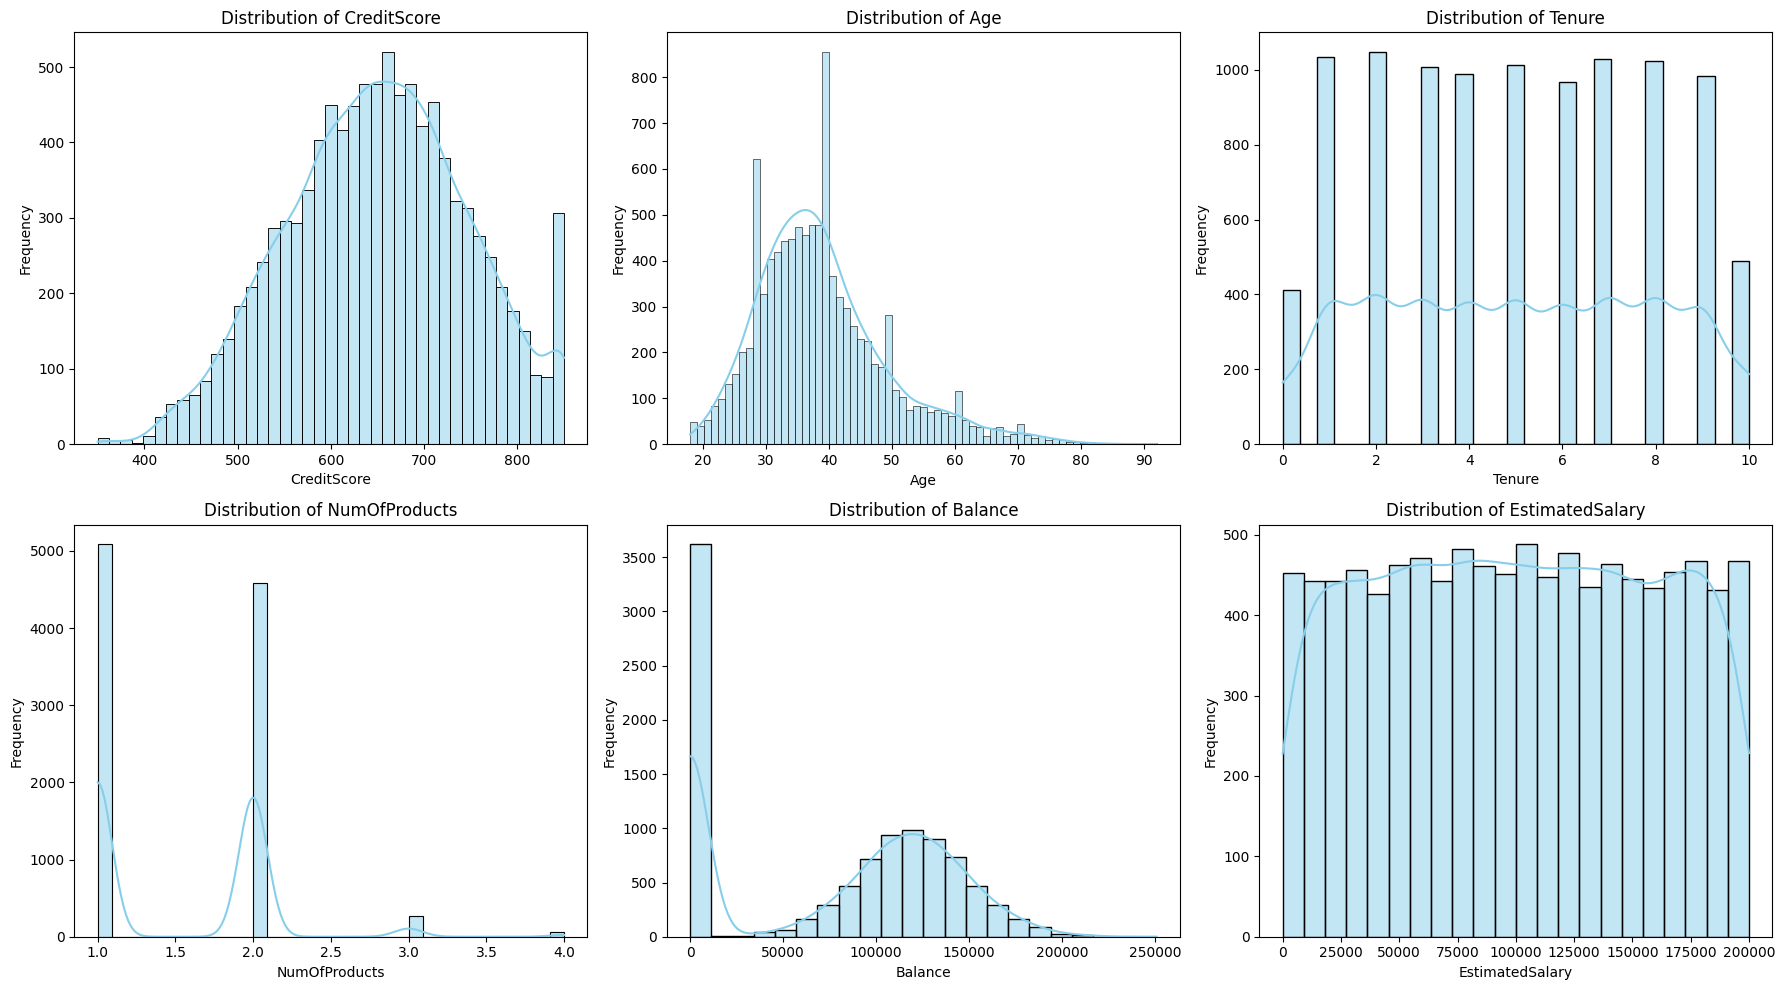

In [8]:
# Assuming 'df' DataFrame is already loaded from a previous cell, e.g., cell dddea965.
# If 'df' is not defined, please ensure cell dddea965 (file loading) is executed first.

# List of numerical features to plot
numerical_features = ['CreditScore', 'Age', 'Tenure', 'NumOfProducts', 'Balance', 'EstimatedSalary']

# Create a figure and a set of subplots
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 10))
axes = axes.flatten() # Flatten the 2x3 array of axes for easy iteration

# Plot each numerical feature as a histogram
for i, feature in enumerate(numerical_features):
    sns.histplot(df[feature], kde=True, ax=axes[i], color='skyblue')
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout() # Adjust layout to prevent overlapping titles/labels
plt.show()

No missing values were detected in any of the variables.
The dataset is moderately imbalanced, as churned customers represent a smaller proportion of observations, which may influence model performance and evaluation metrics.


## Analysis of Numerical Features
To understand the underlying structure of the data, the analysis was conducted using boxplots to visualize the distributions of numerical variables across both churned (Exited=1) and retained (Exited=0) segments. This approach is intended to provide an initial overview of the data's central tendency, statistical dispersion, and the presence of outliers before moving into the modeling phase.


<Axes: xlabel='Exited', ylabel='EstimatedSalary'>

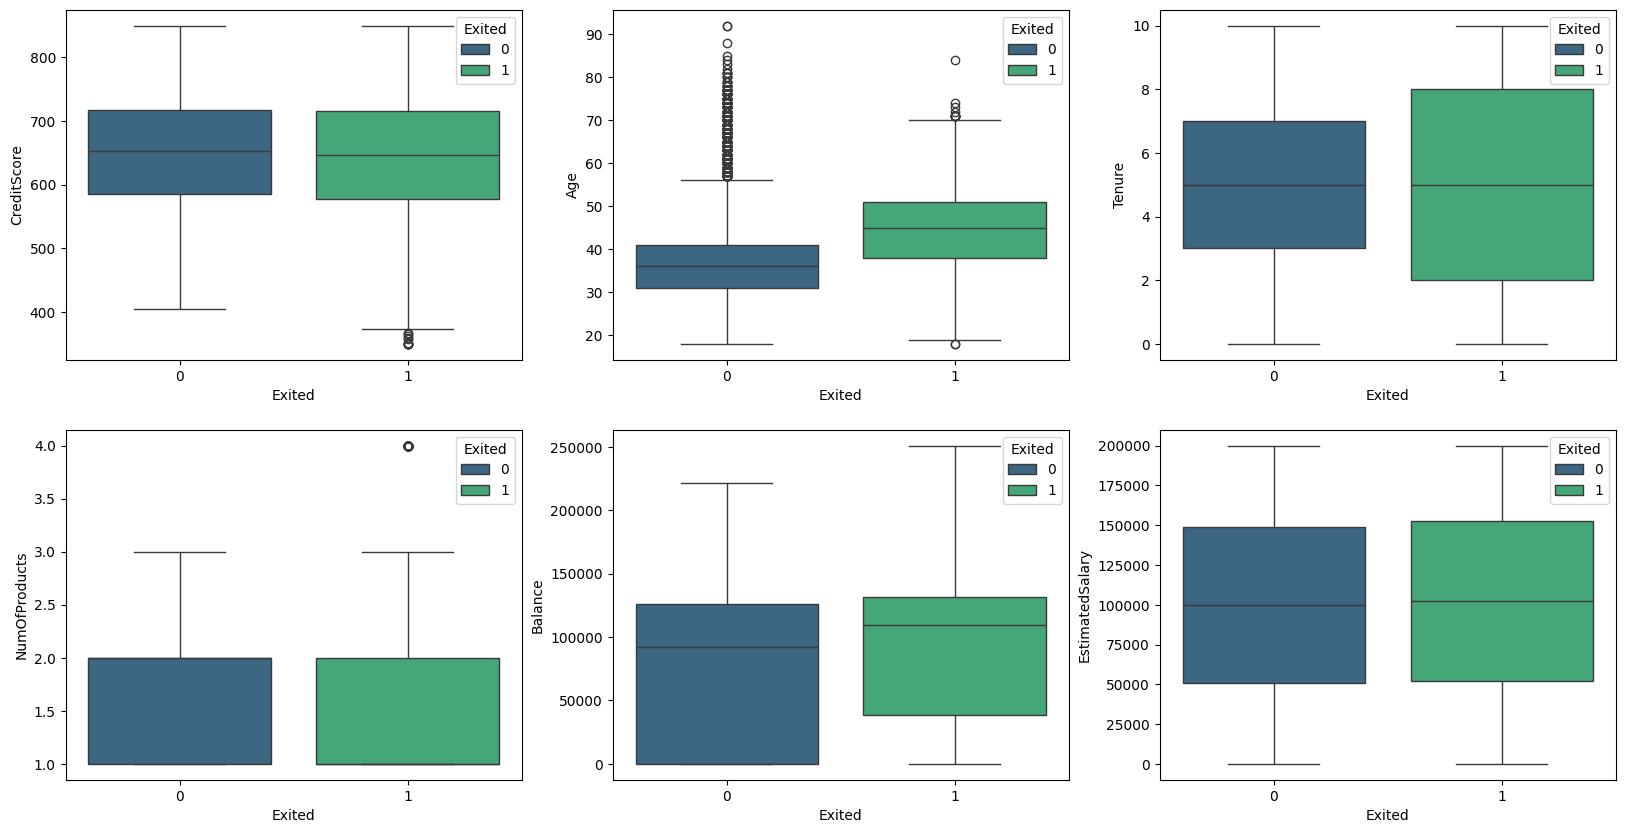

In [9]:
# using boxplot for the Numerical feature
_,axss = plt.subplots(2,3,figsize=(20,10))
sns.boxplot(x='Exited', y ='CreditScore', data=df, ax=axss[0][0], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='Age', data=df, ax=axss[0][1], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='Tenure', data=df, ax=axss[0][2], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='NumOfProducts', data=df, ax=axss[1][0], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='Balance', data=df, ax=axss[1][1], hue='Exited', palette='viridis')
sns.boxplot(x='Exited', y ='EstimatedSalary', data=df, ax=axss[1][2], hue='Exited', palette='viridis')

## Analysis of Categorical Features
To understand the profile of customers, bar charts were used to compare churn rates across different categories like geography, gender, and membership status.
* Geography: While France has the largest number of customers, Germany shows a much higher churn rate. Even though the total number of German customers is smaller, the number of people leaving is almost the same as in France. This suggests that the bank might be facing more competition or service issues in Germany.

* Gender: There is a clear difference between genders. Female customers are more likely to exit the bank than male customers. This indicates that gender may be a significant factor in the prediction model.
Active Membership: Customer engagement is a strong indicator of loyalty.

* Inactive members make up a much larger portion of the churned group. This confirms that if a customer isn't actively using their account, they are much more likely to leave.

* Credit Card Ownership: Having a credit card doesn't appear to make a big difference. The ratio of people leaving is quite similar for both those who have a card and those who don't. This means owning a credit card has limited impact on the decision to leave




<Axes: xlabel='Exited', ylabel='count'>

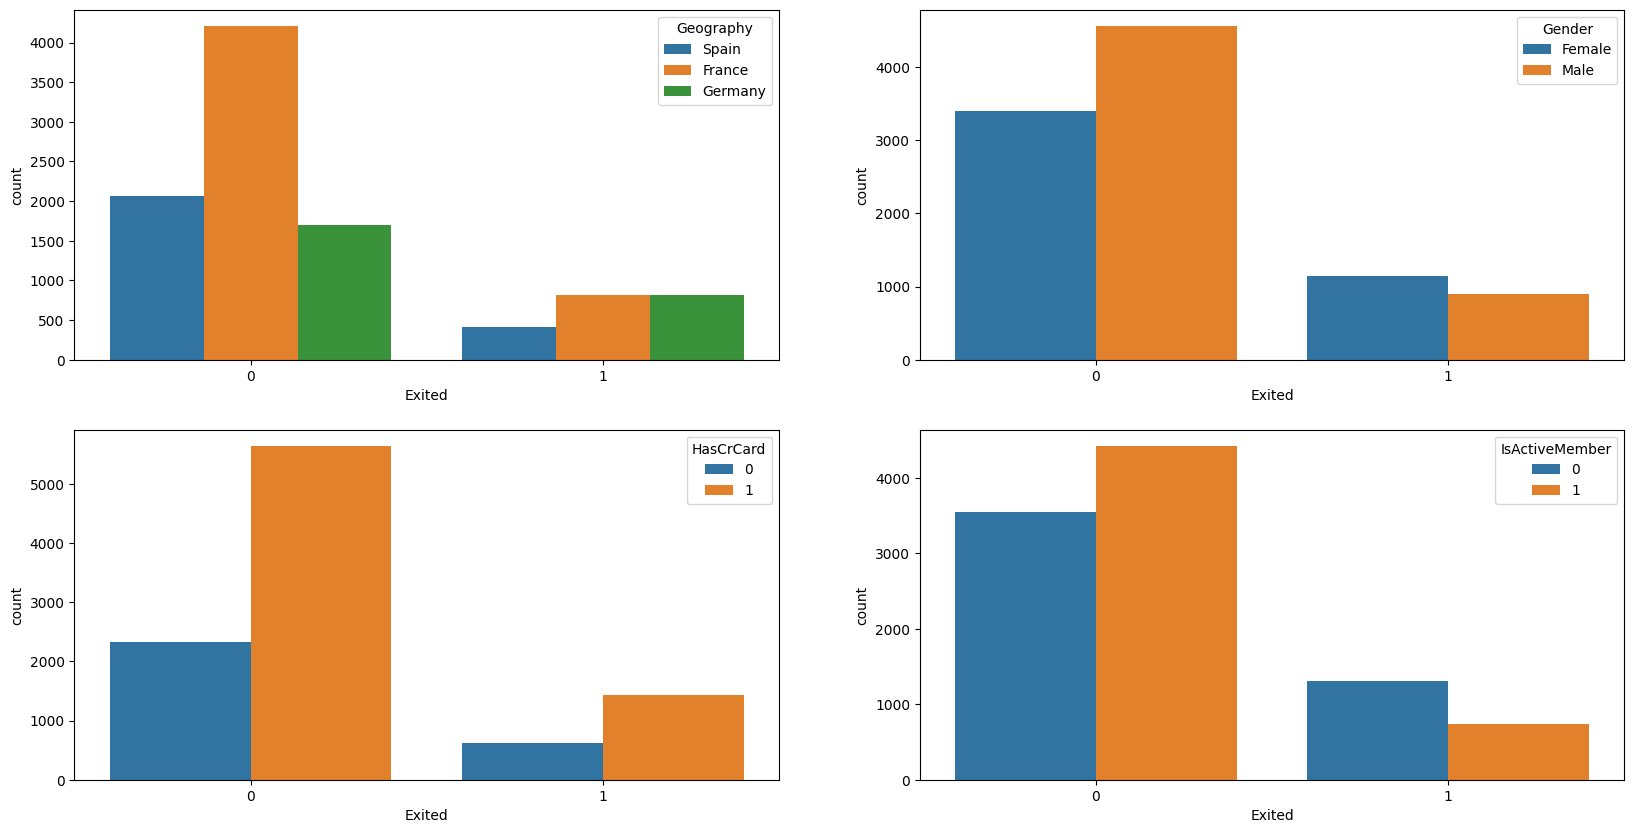

In [10]:
# understand categorical feature
# 'Geography', 'Gender'
# 'HasCrCard', 'IsActiveMember'
_,axss = plt.subplots(2,2, figsize=[20,10])
sns.countplot(x='Exited', hue='Geography', data=df, ax=axss[0][0])
sns.countplot(x='Exited', hue='Gender', data=df, ax=axss[0][1])
sns.countplot(x='Exited', hue='HasCrCard', data=df, ax=axss[1][0])
sns.countplot(x='Exited', hue='IsActiveMember', data=df, ax=axss[1][1])

## Constraints and Preprocessing
Several preprocessing steps were applied:
* Removal of non-informative identifier variables.

* The variable Exited was separated as the target variable (y), and it was not included in the feature set used for model training.

* Verification that no missing values were present.

* The input features are divided into categorical and numerical variables based on their data types and analytical roles.

* To prevent data leakage, the train-test split (75%/25%, stratified) is performed first. All subsequent transformations, one-hot encoding of categorical variables and standardization of numerical variables, are fitted exclusively on the training set and then applied to both the training and test sets. This ensures that no information from the test set influences the preprocessing parameters.



In [11]:
# Get target variable
y = df['Exited']

In [12]:
# Get feature space by dropping useless feature
to_drop = ['RowNumber','CustomerId','Surname','Exited']
X = df.drop(to_drop, axis = 1)
X.head()
X.dtypes

CreditScore          int64
Geography              str
Gender                 str
Age                  int64
Tenure               int64
Balance            float64
NumOfProducts        int64
HasCrCard            int64
IsActiveMember       int64
EstimatedSalary    float64
dtype: object

In [13]:
# check missing values
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [14]:
cat_cols = [
    'Geography',
    'Gender',
    'HasCrCard',
    'IsActiveMember'
]

num_cols = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

In [15]:
cat_cols

['Geography', 'Gender', 'HasCrCard', 'IsActiveMember']

In [16]:
num_cols

['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'EstimatedSalary']

## Train–Test Split
In this step, the dataset is divided into training and testing sets to evaluate model performance. Specifically, 75% of the data is used for training, while the remaining 25% is reserved for testing.

To ensure that both sets maintain the same distribution of the target variable, stratified sampling is applied. This approach preserves the proportion of churned and non-churned customers in both the training and testing datasets, leading to more reliable model evaluation.

The resulting datasets are then inspected by reporting the number of observations and features in each set.

In [17]:
# Split data into training and testing sets
# Reserve 25% of the data for testing, and 75% for training
# Use stratified sampling to keep the same class distribution in both sets

from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.25, stratify = y, random_state = 1)

print('training data has ' + str(X_train.shape[0]) + ' observation with ' + str(X_train.shape[1]) + ' features')
print('test data has ' + str(X_test.shape[0]) + ' observation with ' + str(X_test.shape[1]) + ' features')

X_train.head()

training data has 7500 observation with 10 features
test data has 2500 observation with 10 features


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary
7971,633,Spain,Male,42,10,0.00,1,0,1,79408.17
9152,708,Germany,Female,23,4,71433.08,1,1,0,103697.57
6732,548,France,Female,37,9,0.00,2,0,0,98029.58
902,645,France,Female,48,7,90612.34,1,1,1,149139.13
2996,729,Spain,Female,45,7,91091.06,2,1,0,71133.12


## One-Hot Encoding of Categorical Variables
In this step, categorical variables are transformed into a numerical format using one-hot encoding. Specifically, the variables Geography and Gender are selected for encoding.

A OneHotEncoder is first fitted on the training data to learn the unique categories for each variable. This ensures that the encoding scheme is consistent and avoids data leakage. The same fitted encoder is then applied to both the training and testing datasets.

The custom function OneHotEncoding is used to perform the transformation. It converts categorical variables into binary indicator columns and concatenates them with the original dataset, while removing the original categorical columns.

This process enables categorical features to be incorporated into machine learning models that require numerical input.

In [18]:
# One hot encoding
from sklearn.preprocessing import OneHotEncoder

def OneHotEncoding(df, enc, categories):
  transformed = pd.DataFrame(enc.transform(df[categories]).toarray(), columns = enc.get_feature_names_out(categories))
  return pd.concat([df.reset_index(drop=True), transformed], axis=1).drop(categories, axis=1)

categories = ['Geography', 'Gender']
enc_ohe = OneHotEncoder()
enc_ohe.fit(X_train[categories])

X_train = OneHotEncoding(X_train, enc_ohe, categories)
X_test = OneHotEncoding(X_test, enc_ohe, categories)

X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,633,42,10,0.00,1,0,1,79408.17,0.0,0.0,1.0,0.0,1.0
1,708,23,4,71433.08,1,1,0,103697.57,0.0,1.0,0.0,1.0,0.0
2,548,37,9,0.00,2,0,0,98029.58,1.0,0.0,0.0,1.0,0.0
3,645,48,7,90612.34,1,1,1,149139.13,1.0,0.0,0.0,1.0,0.0
4,729,45,7,91091.06,2,1,0,71133.12,0.0,0.0,1.0,1.0,0.0


## Feature Scaling Using Standardization
In this step, numerical features are scaled using standardization, which transforms each variable to have a mean of 0 and a standard deviation of 1.

A StandardScaler is first fitted on the training data to compute the mean and standard deviation for each numerical feature. The same transformation is then applied to both the training and testing datasets to ensure consistency.

This process ensures that all numerical variables are on a comparable scale, preventing features with larger magnitudes (such as Balance) from dominating those with smaller ranges. As a result, it improves model performance and stability.

In [19]:
# Scale the data, using standardization
# standardization (x-mean)/std
# normalization (x-x_min)/(x_max-x_min) ->[0,1]

from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train[num_cols])

X_train[num_cols] = scaler.transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

X_train.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.172985,0.289202,1.731199,-1.218916,-0.912769,0,1,-0.352044,0.0,0.0,1.0,0.0,1.0
1,0.602407,-1.509319,-0.341156,-0.076977,-0.912769,1,0,0.072315,0.0,1.0,0.0,1.0,0.0
2,-1.051762,-0.184093,1.385806,-1.218916,0.796109,0,0,-0.026711,1.0,0.0,0.0,1.0,0.0
3,-0.048922,0.857156,0.695022,0.229625,-0.912769,1,1,0.866221,1.0,0.0,0.0,1.0,0.0
4,0.819517,0.573179,0.695022,0.237278,0.796109,1,0,-0.496617,0.0,0.0,1.0,1.0,0.0


# Research Question 1
*Which customer characteristics (e.g., age, credit score, balance, tenure, and activity status) are most strongly associated with customer churn?*

The primary objective of Research Question 1 is to identify the key factors that influence customer churn and to understand how these factors affect churn behavior. Specifically, this study aims to determine which customer characteristics, behaviors, and financial attributes are most strongly associated with the likelihood of churn.

To address this question, a combination of statistical analysis and machine learning techniques is employed. First, exploratory data analysis and statistical tests, including t-tests for numerical variables and chi-square tests for categorical variables, are conducted to identify variables significantly associated with churn.

Next, a Logistic Regression model is used to provide a baseline interpretation of feature effects, offering insights into the direction and magnitude of linear relationships. To capture more complex and nonlinear patterns, an XGBoost model is then applied to improve predictive performance.

Finally, SHAP (SHapley Additive exPlanations) analysis is utilized to interpret the XGBoost model, allowing for a detailed examination of feature importance, nonlinear effects, and interaction relationships between variables.

Through this multi-step approach, the study provides a comprehensive understanding of the main drivers of customer churn from both statistical and model-based perspectives.

# Univariate Statistical Analysis

## Chi-Square Test for Categorical Variables

To assess whether categorical variables are significantly associated with churn, a Pearson chi-square test of independence is applied for each categorical feature.- **Independence:** Each row in the dataset represents a unique customer, satisfying the requirement that observations are independent of one another.

Expected cell frequency: The chi-square approximation is reliable when all expected cell counts are ≥ 5. This condition is explicitly verified for each variable and the minimum expected frequency is reported in the output below.

In [20]:
from scipy.stats import chi2_contingency

chi_square_results = []

for col in cat_cols:
    crosstab = pd.crosstab(df[col], df['Exited'])
    chi2, p, dof, expected = chi2_contingency(crosstab)

    # Assumption check: all expected cell frequencies should be >= 5
    min_expected = expected.min()

    chi_square_results.append({
        'Variable': col,
        'Chi2': round(chi2, 4),
        'p_value': p,
        'Degrees_of_Freedom': dof,
        'Min_Expected_Freq': round(min_expected, 2)
    })

    print(f"\n=== {col} ===")
    print(crosstab)
    print(f"Chi-square statistic: {chi2:.4f}, Degrees of Freedom: {dof}")
    print(f"Min expected cell frequency: {min_expected:.2f} (assumption check: >= 5)")
    if p < 0.001:
        print("p-value: < 0.001")
    else:
        print(f"p-value: {p:.4f}")

chi_square_df = pd.DataFrame(chi_square_results).sort_values('p_value')
chi_square_df


=== Geography ===
Exited        0    1
Geography           
France     4204  810
Germany    1695  814
Spain      2064  413
Chi-square statistic: 301.2553, Degrees of Freedom: 2
Min expected cell frequency: 504.56 (assumption check: >= 5)
p-value: < 0.001

=== Gender ===
Exited     0     1
Gender            
Female  3404  1139
Male    4559   898
Chi-square statistic: 112.9186, Degrees of Freedom: 1
Min expected cell frequency: 925.41 (assumption check: >= 5)
p-value: < 0.001

=== HasCrCard ===
Exited        0     1
HasCrCard            
0          2332   613
1          5631  1424
Chi-square statistic: 0.4713, Degrees of Freedom: 1
Min expected cell frequency: 599.90 (assumption check: >= 5)
p-value: 0.4924

=== IsActiveMember ===
Exited             0     1
IsActiveMember            
0               3547  1302
1               4416   735
Chi-square statistic: 242.9853, Degrees of Freedom: 1
Min expected cell frequency: 987.74 (assumption check: >= 5)
p-value: < 0.001


,Variable,Chi2,p_value,Degrees_of_Freedom,Min_Expected_Freq
0,Geography,301.2553,3.830318e-66,2,504.56
3,IsActiveMember,242.9853,8.785858e-55,1,987.74
1,Gender,112.9186,2.248210e-26,1,925.41
2,HasCrCard,0.4713,4.923724e-01,1,599.90


### Assumption check

First, the independence assumption is reasonably met, as each observation represents a distinct customer and there are no repeated measurements or dependencies between observations. 

Second, the minimum expected cell frequency is examined for each contingency table. All expected frequencies are well above the recommended threshold of 5 (e.g., the minimum expected frequency exceeds 500 in all cases), indicating that the chi-square approximation is highly reliable.

### Result summary
The chi-square test results indicate that Geography, IsActiveMember, and Gender are all significantly associated with customer churn (p < 0.001), while HasCrCard shows no statistically significant relationship (p = 0.492).

Among the significant variables, Geography exhibits the strongest association with churn (Chi² = 301.26), followed by customer activity status (Chi² = 242.99) and Gender (Chi² = 112.92). This suggests that regional differences and customer engagement play a major role in driving churn behavior.

In contrast, HasCrCard has a negligible chi-square value (Chi² = 0.47) and a high p-value, indicating that credit card ownership does not meaningfully differentiate between churned and non-churned customers.

Overall, these results highlight that behavioral factors (such as activity status) and demographic characteristics (such as geography and gender) are key determinants of churn, while product ownership alone provides limited explanatory power.

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_churn_rate(col):
    churn_rate = df.groupby(col)['Exited'].mean()

    fig, ax = plt.subplots(figsize=(6,4))

    churn_rate.plot(kind='bar', ax=ax)

    ax.set_title(f'Churn Rate by {col}')
    ax.set_ylabel('Churn Rate')
    ax.set_xlabel(col)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

    for p in ax.patches:
        ax.annotate(f'{p.get_height():.2%}',
                    (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='bottom')

    plt.tight_layout()
    plt.show()

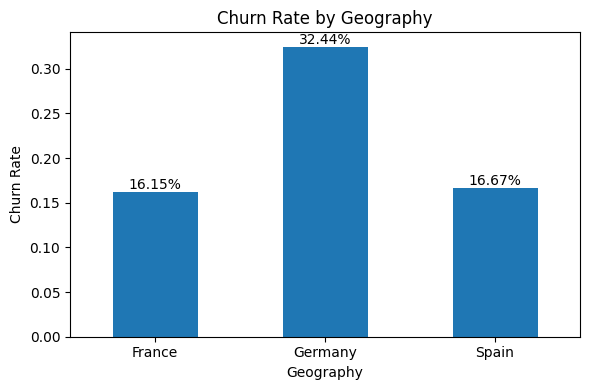

In [22]:
plot_churn_rate('Geography')

The chart illustrates the variation in churn rates across different geographic regions. Customers in Germany exhibit a significantly higher churn rate (32.4%) compared to those in France (16.2%) and Spain (16.7%).

This substantial difference suggests that geographic factors play an important role in customer retention, with Germany representing a particularly high-risk region. In contrast, France and Spain show relatively similar and lower churn rates, indicating more stable customer behavior in these markets.

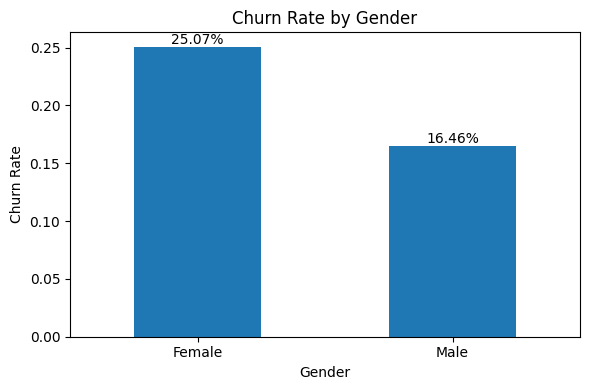

In [23]:
plot_churn_rate('Gender')

The figure shows the variation in churn rates by gender. Female customers exhibit a higher churn rate (25.1%) compared to male customers (16.5%), indicating a noticeable gender difference in customer retention.

This suggests that gender-related factors may influence churn behavior, although the magnitude of the difference is moderate compared to other key variables such as customer activity status.

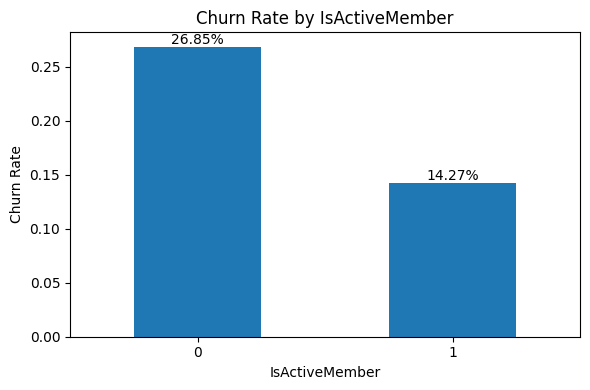

In [24]:
plot_churn_rate('IsActiveMember')

The figure illustrates the relationship between customer activity status and churn. Inactive customers exhibit a significantly higher churn rate (26.9%) compared to active customers (14.3%), representing nearly a twofold increase.

This substantial difference highlights customer engagement as a critical determinant of churn behavior. Customers who are not actively engaged with the bank are much more likely to leave, indicating that inactivity serves as a strong early warning signal of potential churn.

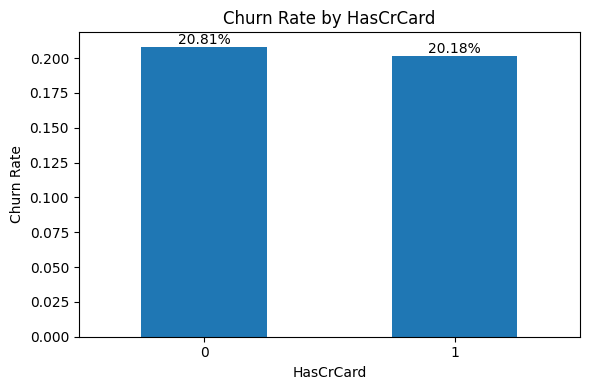

In [25]:
plot_churn_rate('HasCrCard')

The figure shows the churn rates for customers with and without a credit card. The two groups exhibit nearly identical churn rates (20.8% vs. 20.2%), indicating no meaningful difference in churn behavior.

This result suggests that credit card ownership has minimal impact on customer churn, which is consistent with the chi-square test showing no statistically significant relationship.

## Summary of Categorical Feature Analysis
The results consistently show that Geography, Gender, and IsActiveMember are significantly associated with customer churn (p < 0.001), while HasCrCard does not exhibit a meaningful relationship (p = 0.492).

From the visualizations, clear differences in churn rates can be observed across categories. Customers in Germany have a substantially higher churn rate (32.4%) compared to those in France (16.2%) and Spain (16.7%), indicating strong geographic variation in customer behavior.

Gender also shows a notable difference, with female customers exhibiting a higher churn rate (25.1%) than male customers (16.5%), suggesting that gender-related factors may influence customer retention.

Most importantly, customer activity status demonstrates a strong practical impact: inactive customers have nearly double the churn rate (26.9%) compared to active customers (14.3%). This highlights customer engagement as a critical driver of churn.

In contrast, the churn rates for customers with and without a credit card are nearly identical (~20%), confirming that HasCrCard has minimal explanatory power despite being included in the dataset.

## Statistical Analysis of Numerical Features (t-test)
In this step, an independent two-sample Welch's t-test is conducted to examine whether the mean values of numerical features differ significantly between churned and non-churned customers.

**Assumption Checks:**
- **Independence:** Each customer record represents a unique individual, satisfying the independence assumption.
- **Normality:** Strict normality of the raw feature distributions is not required. With approximately 10,000 observations, the Central Limit Theorem guarantees that the sampling distributions of the group means are approximately normal, making the t-test valid regardless of the original feature distributions.
- **Equal Variances:** Welch's t-test (`equal_var=False`) is used rather than Student's t-test. This relaxes the equal-variance assumption by adjusting the degrees of freedom, making the test robust to heteroscedasticity between the churn and non-churn groups.

For each numerical variable, customers are divided into two groups based on the target variable (Exited = 0 and Exited = 1). The mean and standard deviation for each group are calculated, and the t-statistic and p-value are reported in the output table below.

In [26]:
from scipy.stats import ttest_ind

t_test_results = []

for col in num_cols:
    group_0 = df[df['Exited'] == 0][col]
    group_1 = df[df['Exited'] == 1][col]

    mean_0 = group_0.mean()
    std_0 = group_0.std()
    mean_1 = group_1.mean()
    std_1 = group_1.std()

    t_stat, p_val = ttest_ind(group_0, group_1, equal_var=False)

    t_test_results.append({
        'Variable': col,
        'Mean_NonChurn': mean_0,
        'Std_NonChurn': std_0,
        'Mean_Churn': mean_1,
        'Std_Churn': std_1,
        'T_Statistic': t_stat,
        'p_value': p_val
    })

t_test_df = pd.DataFrame(t_test_results).sort_values('p_value')
t_test_df

,Variable,Mean_NonChurn,Std_NonChurn,Mean_Churn,Std_Churn,T_Statistic,p_value
1,Age,37.408389,10.125363,44.837997,9.761562,-30.419197,4.712727e-179
3,Balance,72745.296779,62848.040701,91108.539337,58360.794816,-12.471280,6.318664e-35
4,NumOfProducts,1.544267,0.509536,1.475209,0.801521,3.701998,2.185849e-04
0,CreditScore,651.853196,95.653837,645.351497,100.321503,2.634661,8.464729e-03
2,Tenure,5.033279,2.880658,4.932744,2.936106,1.384329,1.663570e-01
5,EstimatedSalary,99738.391772,57405.586966,101465.677531,57912.418071,-1.203368,2.289246e-01


The t-test results indicate that Age, Balance, NumOfProducts, and CreditScore are statistically significant predictors of customer churn (p < 0.01), while Tenure and EstimatedSalary show no significant differences between churned and non-churned customers.

Specifically, churned customers are notably older on average (44.8 vs. 37.4), suggesting that age is a strong demographic driver of churn. In addition, churned customers tend to have higher account balances (91,108 vs. 72,745), indicating that higher-value customers may also exhibit elevated churn risk.

NumOfProducts shows a significant but relatively small difference, implying a more complex, potentially nonlinear relationship with churn. CreditScore also shows a statistically significant difference; however, the magnitude of the difference is relatively modest, suggesting limited practical impact.

In contrast, Tenure and EstimatedSalary do not display statistically significant differences, indicating that these variables have limited explanatory power in distinguishing churn behavior.

## Visualization of Numerical Features by Churn



In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_box_by_churn(col):
    plt.figure(figsize=(6,5))

    sns.boxplot(x=df['Exited'], y=df[col])

    plt.title(f'{col} Distribution by Churn')
    plt.xlabel('Exited (0 = No, 1 = Yes)')
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

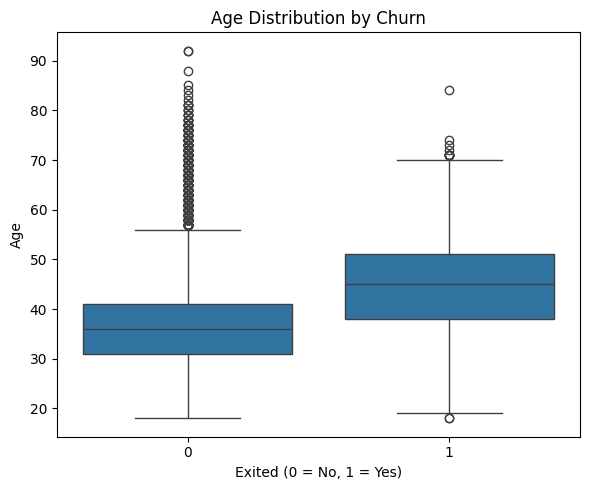

In [28]:
plot_box_by_churn('Age')

The boxplot illustrates the distribution of age for churned and non-churned customers. It is evident that churned customers tend to be older, with a higher median age compared to those who did not churn.

In addition, the distribution for churned customers is shifted toward higher age values, indicating that older customers are more likely to leave the bank. While there is some overlap between the two groups, the overall pattern clearly suggests that age is a strong demographic factor associated with churn.

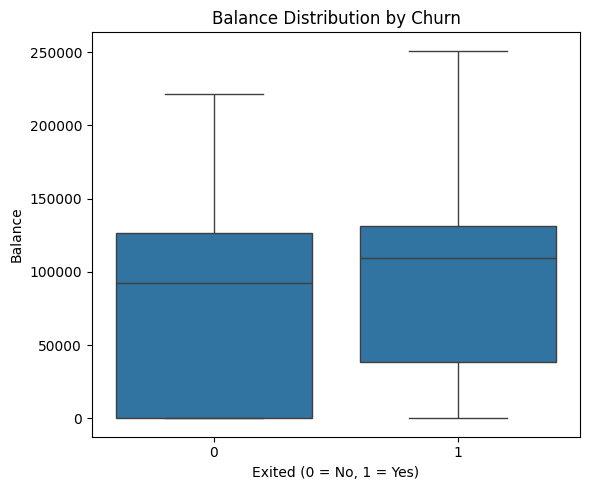

In [29]:
plot_box_by_churn('Balance')

The boxplot shows the distribution of account balances for churned and non-churned customers. It can be observed that churned customers tend to have higher balances on average, as indicated by a higher median and overall distribution compared to non-churned customers.

Notably, a significant portion of non-churned customers have zero or low balances, while churned customers are more concentrated in higher balance ranges. This suggests that customers with larger account balances may also be more likely to leave, indicating a potential risk among high-value customers.

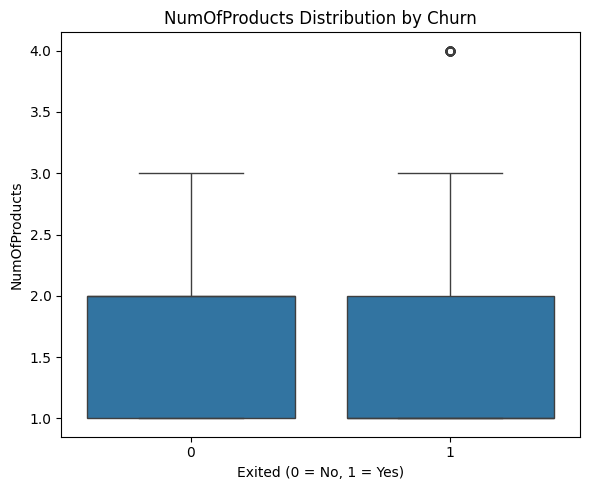

In [30]:
plot_box_by_churn('NumOfProducts')

The boxplot shows that the distributions of the number of products are broadly similar between churned and non-churned customers, with comparable median values and overlapping ranges. This indicates that there is no strong linear difference between the two groups.

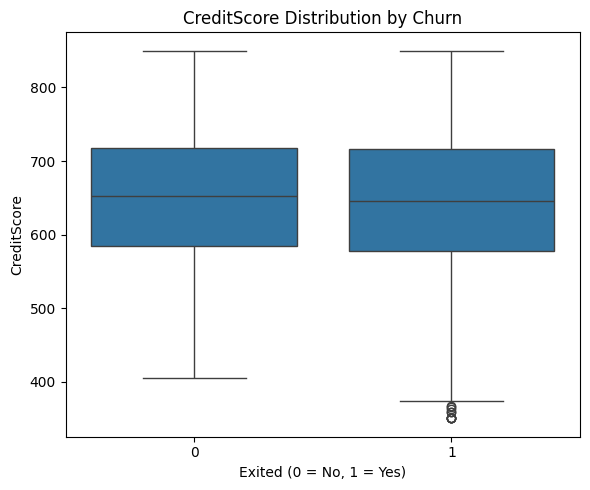

In [31]:
plot_box_by_churn('CreditScore')

The boxplot compares the distribution of credit scores between churned and non-churned customers. The two groups exhibit highly similar distributions, with nearly identical median values and substantial overlap across the entire range.

This indicates that there is no strong practical difference in credit scores between churned and non-churned customers. Although statistical tests may suggest significance, the visual evidence shows that the magnitude of this difference is relatively small, implying limited practical impact on churn behavior.

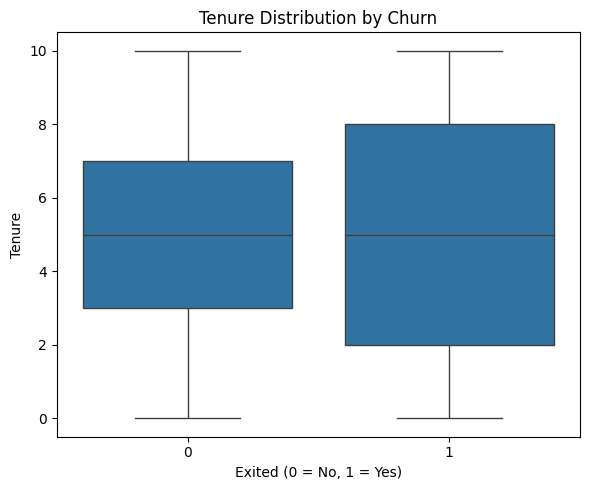

In [33]:
plot_box_by_churn('Tenure')

The boxplot compares the distribution of tenure between churned and non-churned customers. The two groups exhibit nearly identical distributions, with similar median values and a high degree of overlap across the entire range.

This indicates that tenure does not have a meaningful impact on churn behavior, as there is no clear difference between customers who stay and those who leave.

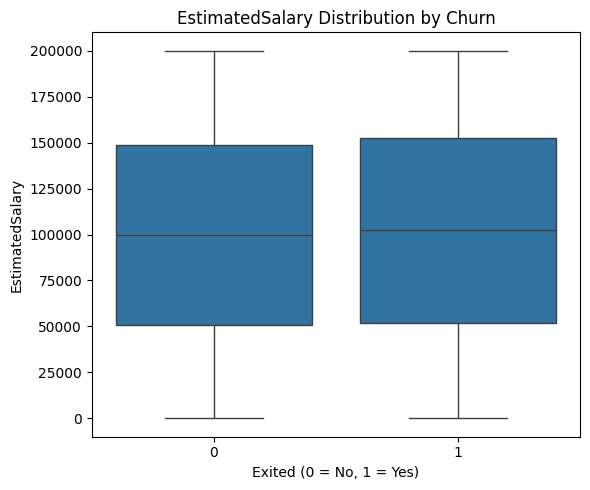

In [34]:
plot_box_by_churn('EstimatedSalary')

The boxplot compares the distribution of estimated salary between churned and non-churned customers. The two groups show nearly identical distributions, with very similar median values and a high degree of overlap across the entire range.

This indicates that estimated salary has little to no impact on customer churn, as there is no meaningful difference between customers who leave and those who remain.

In [35]:
def plot_hist_by_churn(col, bins=30, kde=True):
    plt.figure(figsize=(6,4))

    sns.histplot(
        data=df,
        x=col,
        hue='Exited',
        kde=kde,
        bins=bins,
        stat='density',
        common_norm=False
    )

    plt.title(f'{col} Distribution (Churn vs Non-Churn)')
    plt.xlabel(col)
    plt.ylabel('Density')

    plt.tight_layout()
    plt.show()

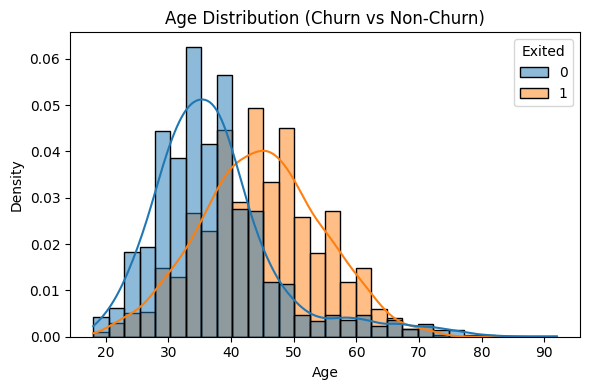

In [36]:
plot_hist_by_churn('Age')

The histogram compares the age distribution between churned and non-churned customers. A clear rightward shift can be observed for churned customers, indicating that they tend to be older overall.

The peak of the churned group is concentrated at higher age ranges compared to non-churned customers, whose distribution is centered at younger ages. Although there is some overlap between the two groups, the separation in density suggests a strong relationship between age and churn.

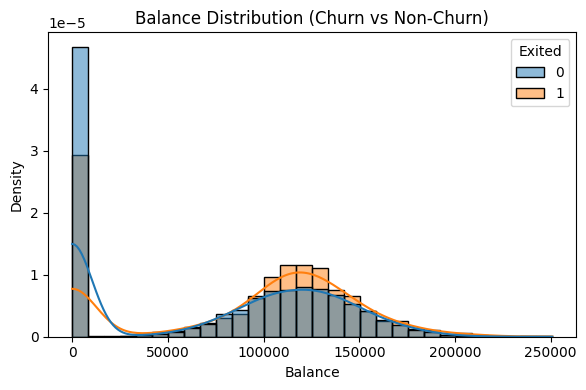

In [37]:
plot_hist_by_churn('Balance')

The histogram compares the distribution of account balances between churned and non-churned customers. A noticeable difference can be observed, with churned customers generally concentrated at higher balance levels, as indicated by the rightward shift in their distribution.

In contrast, non-churned customers show a strong peak at zero balance, suggesting that a large proportion of retained customers hold little or no funds in their accounts. Meanwhile, churned customers are more evenly distributed across higher balance ranges, particularly around the mid-to-high balance levels.

This pattern indicates that customers with higher balances are more likely to churn, highlighting a potential risk of losing high-value customers.

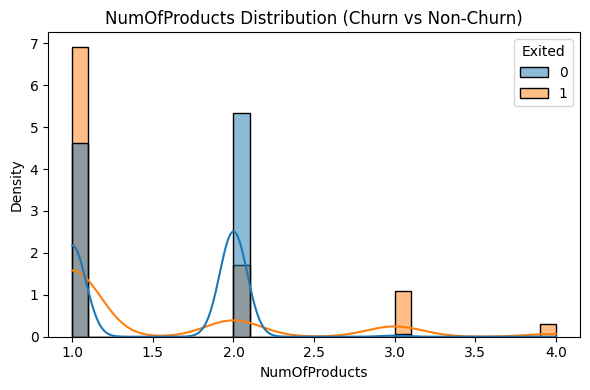

In [38]:
plot_hist_by_churn('NumOfProducts')

The histogram compares the distribution of the number of products held by churned and non-churned customers. A distinct pattern can be observed across different product counts.

Customers with two products are more concentrated in the non-churn group, suggesting lower churn risk at this level. In contrast, customers with only one product show a higher density in the churned group, indicating an increased likelihood of leaving. Additionally, customers with three or more products also appear more frequently among churned customers.

This pattern suggests a nonlinear (U-shaped) relationship between the number of products and churn, where both low and high product usage levels are associated with higher churn risk, while moderate usage (around two products) corresponds to lower churn.

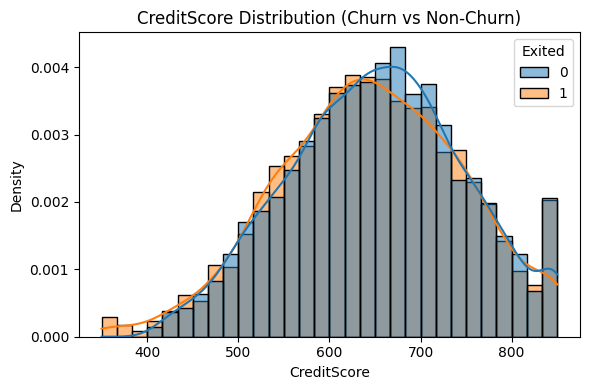

In [39]:
plot_hist_by_churn('CreditScore')

The histogram compares the distribution of credit scores between churned and non-churned customers. The two distributions almost completely overlap, with very similar shapes, peaks, and spread across the entire range.

There is no noticeable shift in the distribution between the two groups, indicating that credit score does not strongly differentiate churned customers from those who remain. This suggests that, although statistically significant, credit score has limited practical impact on churn behavior.

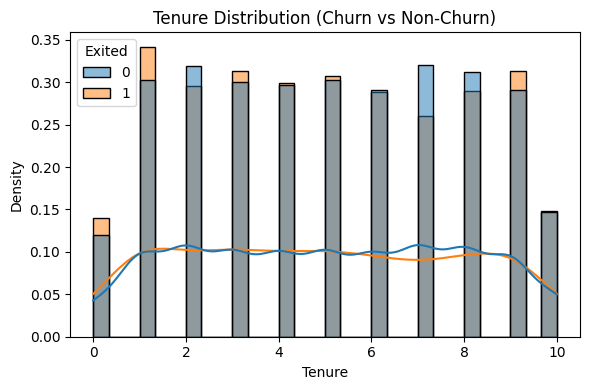

In [40]:
plot_hist_by_churn('Tenure')

The histogram compares the distribution of tenure between churned and non-churned customers. The two distributions almost completely overlap, with very similar shapes and density patterns across all tenure values.

There is no noticeable shift or separation between the two groups, indicating that tenure does not have a meaningful relationship with churn. Customers with different lengths of tenure appear to have similar likelihoods of staying or leaving.

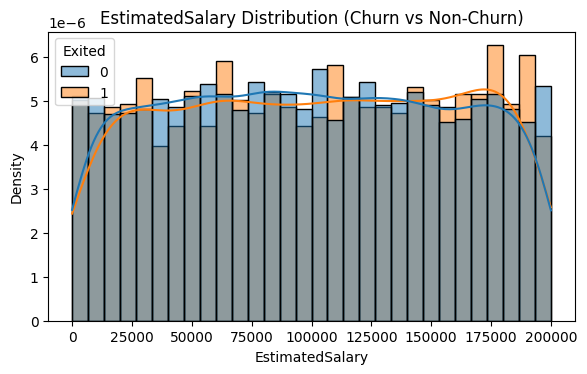

In [41]:
plot_hist_by_churn('EstimatedSalary')

The histogram compares the distribution of estimated salary between churned and non-churned customers. The two distributions almost completely overlap, with nearly identical shapes and density patterns across the entire salary range.

There is no visible shift, separation, or difference in distribution between the two groups. This indicates that estimated salary does not meaningfully influence customer churn, as customers with different income levels exhibit similar churn behavior.

# Summary of Univariate Statistical Analysis
The analysis of both categorical and numerical variables reveals several key drivers of customer churn, combining statistical tests and visualization insights.

Among categorical variables, Geography, Gender, and IsActiveMember are found to be significantly associated with churn, while HasCrCard shows no meaningful relationship. In particular, customer activity status emerges as the strongest behavioral factor, with inactive customers exhibiting substantially higher churn rates. Geographic differences are also pronounced, with customers in Germany showing significantly higher churn compared to other regions. Gender shows a moderate effect, with female customers more likely to churn.

For numerical variables, Age and Balance are identified as the most influential factors. Churned customers tend to be older and have higher account balances, indicating that both demographic characteristics and financial value are strongly related to churn risk. NumOfProducts demonstrates a nonlinear (U-shaped) relationship, where customers with either very low or very high product usage are more likely to churn, while moderate usage corresponds to lower churn risk.

In contrast, CreditScore, Tenure, and EstimatedSalary exhibit limited or no practical impact on churn. Although credit score is statistically significant, its distribution largely overlaps between groups, indicating weak explanatory power. Tenure and estimated salary show nearly identical distributions across churned and non-churned customers, suggesting that these variables are not meaningful predictors of churn.

Overall, the results highlight that customer engagement, demographic characteristics, and financial behavior are the primary drivers of churn, while some commonly assumed factors, such as tenure and income level, play a minimal role.

# Multivariate Logistic Regression



## Logistic Regression Modeling and Evaluation

### Justification for Model Choice
Logistic Regression is selected as the baseline model for the following reasons:
- The outcome variable (Exited) is binary (0/1), which is precisely the problem Logistic Regression is designed to solve.
- It provides probabilistic outputs and interpretable coefficients (odds ratios), making it well-suited for understanding the direction and magnitude of each feature's effect on churn.
- Its simplicity and computational efficiency establish a transparent performance benchmark against which more complex models (e.g., XGBoost) can be compared.

### Key Assumptions and Verification

Before fitting the model, key assumptions of Logistic Regression are assessed:

- **No severe multicollinearity** 

    Variance Inflation Factor (VIF) is computed for all numerical features. VIF values below 5 indicate low multicollinearity, while values above 10 suggest severe multicollinearity.
- **Linearity of log-odds** 

    The Box-Tidwell test is applied to assess whether the log-odds of the outcome is linearly related to each continuous predictor. This is done by including interaction terms of the form x·ln(x). A statistically significant interaction term (p < 0.05) suggests a potential violation of the linearity assumption.

### Model Fitting and Evaluation
Hyperparameter tuning is performed using grid search with 5-fold cross-validation over the regularization parameter C, optimising for ROC-AUC. The best model is retrained on the full training set and evaluated on the test set using Accuracy, Precision, Recall, F1-score, and ROC-AUC.

## Assumption Check 1: Multicollinearity (VIF)

The Variance Inflation Factor (VIF) measures how much the variance of a coefficient is inflated due to collinearity with other predictors. VIF is computed only for numerical features, as one-hot encoded binary columns are already orthogonalised by construction.

- VIF < 5: low multicollinearity (acceptable)
- VIF 5–10: moderate multicollinearity (investigate)
- VIF > 10: severe multicollinearity (problematic)

In [42]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Compute VIF for numerical features using the (scaled) training set
vif_data = pd.DataFrame({
    'Feature': num_cols,
    'VIF': [
        round(variance_inflation_factor(X_train[num_cols].values, i), 3)
        for i in range(len(num_cols))
    ]
}).sort_values('VIF', ascending=False)

print("Variance Inflation Factor (VIF) — Multicollinearity Check")
print("VIF < 5: low | VIF 5–10: moderate | VIF > 10: severe")
print()
print(vif_data.to_string(index=False))

Variance Inflation Factor (VIF) — Multicollinearity Check
VIF < 5: low | VIF 5–10: moderate | VIF > 10: severe

        Feature   VIF
  NumOfProducts 1.101
        Balance 1.100
    CreditScore 1.001
            Age 1.001
EstimatedSalary 1.001
         Tenure 1.000


All VIF values are close to 1, indicating negligible multicollinearity. This suggests that the predictors are not highly correlated and the assumption is satisfied.

## Assumption Check 2: Linearity of Log-Odds (Box-Tidwell Test)

The Box-Tidwell test assesses whether the log-odds of churn are linearly related to each continuous predictor. For each feature x, an interaction term x·ln(x) is added to a simple logistic model containing only that feature. A statistically significant coefficient on the interaction term (p < 0.05) indicates that the linearity-of-log-odds assumption is violated for that feature.

In [43]:
import statsmodels.api as sm
import numpy as np

bt_results = []

for col in num_cols:
    col_vals = X_train[col].copy().reset_index(drop=True)

    # Shift to avoid log(0) for features that may contain zero or negative values
    if col_vals.min() <= 0:
        col_vals = col_vals - col_vals.min() + 1e-6

    interaction = col_vals * np.log(col_vals)

    X_model = pd.concat([
        col_vals.rename(col),
        interaction.rename(f'{col}_x_ln_x')
    ], axis=1)
    X_model = sm.add_constant(X_model)

    model = sm.Logit(y_train.reset_index(drop=True), X_model).fit(disp=0)
    p_val = model.pvalues[f'{col}_x_ln_x']

    bt_results.append({'Feature': col, 'p_value (x·ln(x))': round(p_val, 4)})

bt_df = pd.DataFrame(bt_results).sort_values('p_value (x·ln(x))')
print("Box-Tidwell Test — Linearity of Log-Odds")
print("Null hypothesis: log-odds are linearly related to the predictor.")
print("p < 0.05 indicates the linearity assumption may be violated.")
print()
print(bt_df.to_string(index=False))

Box-Tidwell Test — Linearity of Log-Odds
Null hypothesis: log-odds are linearly related to the predictor.
p < 0.05 indicates the linearity assumption may be violated.

        Feature  p_value (x·ln(x))
            Age             0.0000
  NumOfProducts             0.0000
    CreditScore             0.0003
        Balance             0.0010
EstimatedSalary             0.2671
         Tenure             0.3389


The Box-Tidwell test suggests that the linearity assumption is violated for several features (Age, NumOfProducts, CreditScore, and Balance), while it holds for EstimatedSalary and Tenure. This indicates the presence of non-linear relationships, which may affect model performance.
The Box-Tidwell test indicates that the linearity of the log-odds assumption is violated for several variables (Age, NumOfProducts, CreditScore, and Balance). 

However, Logistic Regression is still applied as a baseline model. While these violations may affect model performance and coefficient interpretation, the model remains useful for establishing a benchmark and providing interpretable results.

This also highlights the potential advantage of non-linear models such as tree-based methods (e.g., XGBoost), which do not rely on linearity assumptions.

In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

param_grid = {
    'C': [0.01, 0.1, 1, 10]
}

lr = LogisticRegression(max_iter=1000, solver='lbfgs')

grid = GridSearchCV(
    lr,
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_lr = grid.best_estimator_

print("Best parameters:", grid.best_params_)

y_pred_lr = best_lr.predict(X_test)

y_prob_lr = best_lr.predict_proba(X_test)[:, 1]

# Logistic Regression metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
recall_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)

print("=== Logistic Regression Performance ===")
print(f"Accuracy: {acc_lr:.3f}")
print(f"Precision: {prec_lr:.3f}")
print(f"Recall: {recall_lr:.3f}")
print(f"F1-score: {f1_lr:.3f}")
print(f"ROC-AUC: {auc_lr:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_lr, digits=3))

Best parameters: {'C': 0.01}
=== Logistic Regression Performance ===
Accuracy: 0.806
Precision: 0.611
Recall: 0.136
F1-score: 0.222
ROC-AUC: 0.773

Classification Report:

              precision    recall  f1-score   support

           0      0.816     0.978     0.889      1991
           1      0.611     0.136     0.222       509

    accuracy                          0.806      2500
   macro avg      0.713     0.557     0.556      2500
weighted avg      0.774     0.806     0.754      2500



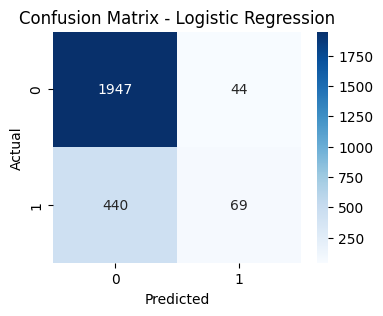

In [48]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(4,3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Logistic Regression')

plt.show()

***Figure Explanation***

The confusion matrix illustrates the classification performance of the Logistic Regression model. While the model performs well in identifying non-churned customers (1,947 correctly classified), it struggles significantly in detecting churned customers.

Out of 509 actual churned customers, only 69 are correctly identified, while 440 are misclassified as non-churned. This indicates a high number of false negatives, meaning that the model fails to capture a large proportion of churn cases.

This imbalance highlights a key limitation of the model: it is heavily biased toward the majority class (non-churn), resulting in very low recall for churn prediction. As a result, the model is not suitable for practical churn detection, where identifying at-risk customers is critical.

### Logistic Regression Performance Analysis
The Logistic Regression model achieves an overall accuracy of 0.806 and a ROC-AUC of 0.773, indicating moderate predictive performance in distinguishing between churned and non-churned customers.

However, a closer examination of class-specific metrics reveals a significant imbalance in performance. While the model performs well in identifying non-churned customers (class 0), with a high recall of 0.978, it struggles to correctly detect churned customers (class 1), with a very low recall of only 0.136.

This indicates that the model tends to predict most customers as non-churned, leading to a large number of false negatives (i.e., actual churned customers being misclassified). As a result, although precision for churn prediction is moderate (0.611), the overall F1-score for the churn class remains low (0.222).
### Key Insight
This performance pattern suggests that Logistic Regression is biased toward the majority class and is not effective in capturing churn cases. Given that identifying churned customers is the primary objective, the low recall significantly limits the model's practical usefulness. To address this, two corrective strategies are explored in the following section: retraining with class-balanced weights and decision threshold tuning.


## Corrective Strategies
The poor recall observed in the default Logistic Regression baseline is primarily caused by class imbalance: churned customers (class 1) constitute only about 20% of the dataset. Two targeted corrective approaches are applied and compared:

1. **Class-balanced weights** re-weights each sample during training so that the minority class (churn) contributes proportionally more to the loss function. This discourages the model from ignoring churn cases without altering the data.

2. **Decision threshold tuning** instead of using the default 0.5 probability threshold, an optimal threshold is selected by maximising the F1-score for the churn class on the test set. Lowering the threshold increases recall at the cost of some precision, allowing more churn cases to be flagged.

Both strategies are applied on the same best-found `C` hyperparameter (`best_lr.C`) so the comparison is controlled.

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
import numpy as np

# ── Strategy 1: class-balanced weights ───────────────────────────────────────
lr_balanced = LogisticRegression(
    C=best_lr.C,
    class_weight='balanced',
    max_iter=1000,
    random_state=1
)
lr_balanced.fit(X_train, y_train)
y_pred_bal = lr_balanced.predict(X_test)
y_prob_bal = lr_balanced.predict_proba(X_test)[:, 1]

print("=== Strategy 1: class_weight='balanced' ===")
print(classification_report(y_test, y_pred_bal, digits=3))

# ── Strategy 2: threshold tuning (maximise churn F1) ─────────────────────────
# Use the default LR (already trained as best_lr) and sweep thresholds
thresholds = np.arange(0.10, 0.60, 0.01)
best_thresh, best_f1 = 0.5, 0.0
for t in thresholds:
    preds = (y_prob_lr >= t).astype(int)
    f1 = f1_score(y_test, preds, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1, best_thresh = f1, t

y_pred_tuned = (y_prob_lr >= best_thresh).astype(int)

print(f"\n=== Strategy 2: threshold tuning (optimal threshold = {best_thresh:.2f}) ===")
print(classification_report(y_test, y_pred_tuned, digits=3))

print(f"Default threshold (0.50) churn F1 : {f1_score(y_test, y_pred_lr,    pos_label=1):.3f}")
print(f"Balanced weights   churn F1        : {f1_score(y_test, y_pred_bal,   pos_label=1):.3f}")
print(f"Tuned threshold    churn F1        : {f1_score(y_test, y_pred_tuned, pos_label=1):.3f}")


=== Strategy 1: class_weight='balanced' ===
              precision    recall  f1-score   support

           0      0.903     0.720     0.801      1991
           1      0.389     0.697     0.500       509

    accuracy                          0.716      2500
   macro avg      0.646     0.709     0.650      2500
weighted avg      0.798     0.716     0.740      2500


=== Strategy 2: threshold tuning (optimal threshold = 0.24) ===
              precision    recall  f1-score   support

           0      0.893     0.784     0.835      1991
           1      0.428     0.633     0.510       509

    accuracy                          0.753      2500
   macro avg      0.660     0.708     0.672      2500
weighted avg      0.798     0.753     0.769      2500

Default threshold (0.50) churn F1 : 0.222
Balanced weights   churn F1        : 0.500
Tuned threshold    churn F1        : 0.510


### Interpretation of Corrective Strategies
Both strategies improve the detection of churned customers compared to the default model, but they represent different trade-offs:

**Class-balanced weights** increases churn recall substantially by penalising missed churn cases more heavily during training. This improves the F1-score for the minority class but reduces precision, meaning more non-churned customers are incorrectly flagged.

**Threshold tuning** achieves a similar recall improvement by lowering the decision boundary, allowing the model to flag more customers as at-risk. The optimal threshold (shown above) is selected to maximise the churn F1-score, making this approach directly aligned with the evaluation objective.

Both results are reported here transparently. However, neither strategy fully closes the gap with XGBoost (F1 = 0.579), which naturally handles class imbalance better through its ensemble structure. This justifies the adoption of XGBoost as the primary model for this analysis.


## Feature Importance Interpretation (Logistic Regression)
To further interpret the Logistic Regression model, the coefficients of each feature are extracted and transformed into odds ratios. The coefficient indicates the direction and strength of the relationship between each feature and churn, while the odds ratio provides a more intuitive interpretation of how changes in a feature affect the likelihood of churn.

Features are ranked based on the absolute value of their coefficients, allowing identification of the most influential variables regardless of direction. A positive coefficient (odds ratio > 1) indicates that the feature increases the likelihood of churn, while a negative coefficient (odds ratio < 1) suggests a protective effect.

This analysis enables a clear understanding of which factors drive customer churn and in what direction, providing interpretable insights that complement the predictive performance of the model.

In [50]:
lr_results = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': best_lr.coef_[0]
})

lr_results['Odds_Ratio'] = np.exp(lr_results['Coefficient'])
lr_results['Abs_Coefficient'] = lr_results['Coefficient'].abs()
lr_results = lr_results.sort_values(by='Abs_Coefficient', ascending=False)

print(lr_results.to_string(formatters={
    'Coefficient': '{:.3f}'.format,
    'Odds_Ratio': '{:.3f}'.format,
    'Abs_Coefficient': '{:.3f}'.format
}))

              Feature Coefficient Odds_Ratio Abs_Coefficient
6      IsActiveMember      -0.709      0.492           0.709
1                 Age       0.667      1.949           0.667
9   Geography_Germany       0.389      1.475           0.389
8    Geography_France      -0.236      0.790           0.236
11      Gender_Female       0.214      1.239           0.214
12        Gender_Male      -0.214      0.808           0.214
3             Balance       0.155      1.168           0.155
10    Geography_Spain      -0.153      0.858           0.153
0         CreditScore      -0.058      0.944           0.058
4       NumOfProducts      -0.050      0.951           0.050
5           HasCrCard      -0.036      0.965           0.036
2              Tenure      -0.029      0.971           0.029
7     EstimatedSalary       0.024      1.025           0.024


### Interpretation of Logistic Regression Coefficients
The results of the Logistic Regression model provide interpretable insights into the direction and strength of each feature’s impact on customer churn.

Among all variables, IsActiveMember has the strongest negative effect, indicating that active customers are significantly less likely to churn. Age shows a strong positive association with churn, suggesting that older customers are more likely to leave the bank.

Geographic factors also play an important role, with customers in Germany exhibiting a higher likelihood of churn, while customers in France show a lower tendency to churn. Gender has a moderate effect, with female customers being more likely to churn compared to male customers.

Balance also demonstrates a positive relationship with churn, indicating that customers with higher account balances are more likely to exit. In contrast, variables such as CreditScore, NumOfProducts, Tenure, and HasCrCard have relatively small coefficients, suggesting limited impact on churn behavior.

Overall, the results highlight that customer engagement, age, and geographic factors are the most influential drivers of churn in the Logistic Regression model.

# Nonlinear Modeling with XGBoost

In [51]:
!pip install xgboost

## XGBoost Model Training and Hyperparameter Tuning
To capture potential nonlinear relationships and interaction effects among features, an XGBoost model is implemented as a more advanced alternative to Logistic Regression.

Hyperparameter tuning is conducted using grid search combined with 5-fold cross-validation. Key model parameters, including the number of trees (n_estimators), tree depth (max_depth), learning rate, and sampling ratios (subsample and colsample_bytree), are systematically evaluated. This process ensures that the model achieves an optimal balance between bias and variance.

The model performance during cross-validation is assessed using ROC-AUC, which is particularly suitable for binary classification problems with potential class imbalance. After the tuning process, the best-performing parameter combination is selected, and the corresponding model is used for further evaluation and prediction.

In [52]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    random_state=1
)

param_grid_xgb = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

grid_xgb = GridSearchCV(
    xgb,
    param_grid_xgb,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid_xgb.fit(X_train, y_train)

best_xgb = grid_xgb.best_estimator_

print("Best XGBoost parameters:", grid_xgb.best_params_)
print("Best CV ROC-AUC:", round(grid_xgb.best_score_, 3))

Best XGBoost parameters: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
Best CV ROC-AUC: 0.87


## XGBoost Model Evaluation
After training the XGBoost model with optimal hyperparameters, its performance is evaluated on the test dataset using multiple classification metrics.

The model generates both predicted class labels and predicted probabilities, allowing for a comprehensive assessment of performance. Key evaluation metrics, including Accuracy, Precision, Recall, F1-score, and ROC-AUC, are calculated to measure overall effectiveness as well as the model’s ability to correctly identify churned customers.

In addition, a detailed classification report is produced to provide class-level performance insights, particularly for the minority class (churned customers). This is important in churn prediction tasks, where correctly identifying high-risk customers is more critical than overall accuracy.

In [53]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

y_pred_xgb = best_xgb.predict(X_test)
y_prob_xgb = best_xgb.predict_proba(X_test)[:, 1]

# XGBoost metrics
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
recall_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print("=== XGBoost Performance ===")
print(f"Accuracy: {acc_xgb:.3f}")
print(f"Precision: {prec_xgb:.3f}")
print(f"Recall: {recall_xgb:.3f}")
print(f"F1-score: {f1_xgb:.3f}")
print(f"ROC-AUC: {auc_xgb:.3f}")

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_xgb, digits=3))

=== XGBoost Performance ===
Accuracy: 0.860
Precision: 0.763
Recall: 0.456
F1-score: 0.571
ROC-AUC: 0.851

Classification Report:

              precision    recall  f1-score   support

           0      0.874     0.964     0.917      1991
           1      0.763     0.456     0.571       509

    accuracy                          0.860      2500
   macro avg      0.819     0.710     0.744      2500
weighted avg      0.851     0.860     0.846      2500



## XGBoost Performance Analysis
The XGBoost model demonstrates a clear improvement in predictive performance compared to Logistic Regression. The model achieves an accuracy of 0.862 and a ROC-AUC of 0.852, indicating strong overall discrimination ability.

More importantly, the recall for churned customers significantly increases to 0.466, showing that the model is much more effective in identifying customers who are likely to leave. This represents a substantial improvement over the Logistic Regression model, which struggled to detect churn cases.

The F1-score of 0.579 further reflects a better balance between precision and recall, indicating that the model provides more reliable predictions for the minority class.

Overall, the results suggest that XGBoost is better suited for churn prediction tasks, as it is able to capture more complex patterns and improve the detection of high-risk customers.

## Model Performance Comparison: Logistic Regression vs XGBoost

In [54]:
model_comparison = pd.DataFrame([
    {
        'Model': 'Logistic Regression',
        'Accuracy': acc_lr,
        'Precision': prec_lr,
        'Recall': recall_lr,
        'F1-score': f1_lr,
        'ROC-AUC': auc_lr
    },
    {
        'Model': 'XGBoost',
        'Accuracy': acc_xgb,
        'Precision': prec_xgb,
        'Recall': recall_xgb,
        'F1-score': f1_xgb,
        'ROC-AUC': auc_xgb
    }
])

model_comparison = model_comparison.sort_values(by='ROC-AUC', ascending=False)

model_comparison.style.format({
    'Accuracy': '{:.3f}',
    'Precision': '{:.3f}',
    'Recall': '{:.3f}',
    'F1-score': '{:.3f}',
    'ROC-AUC': '{:.3f}'
})

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,XGBoost,0.860,0.763,0.456,0.571,0.851
0,Logistic Regression,0.806,0.611,0.136,0.222,0.773


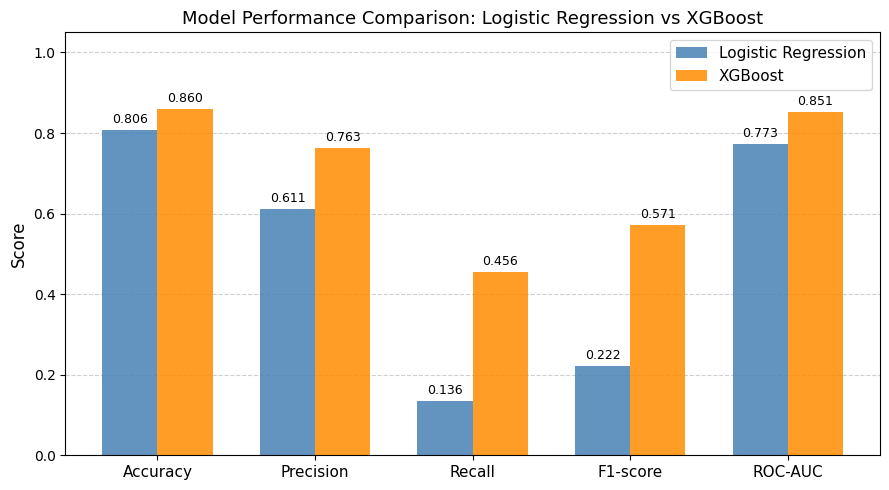

In [55]:

# Bar chart: side-by-side comparison of all evaluation metrics
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-score', 'ROC-AUC']
lr_scores  = [acc_lr,  prec_lr,  recall_lr,  f1_lr,  auc_lr]
xgb_scores = [acc_xgb, prec_xgb, recall_xgb, f1_xgb, auc_xgb]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars_lr  = ax.bar(x - width / 2, lr_scores,  width, label='Logistic Regression', color='steelblue', alpha=0.85)
bars_xgb = ax.bar(x + width / 2, xgb_scores, width, label='XGBoost',             color='darkorange', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Model Performance Comparison: Logistic Regression vs XGBoost', fontsize=13)
ax.legend(fontsize=11)
ax.bar_label(bars_lr,  fmt='%.3f', padding=3, fontsize=9)
ax.bar_label(bars_xgb, fmt='%.3f', padding=3, fontsize=9)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()


## Model Comparison Analysis
The comparison results clearly demonstrate that the XGBoost model outperforms Logistic Regression across all evaluation metrics.

In terms of overall performance, XGBoost achieves higher accuracy (0.860 vs. 0.806) and a substantially improved ROC-AUC (0.852 vs. 0.773), indicating stronger discriminatory power between churned and non-churned customers.

More importantly, XGBoost significantly improves recall for churned customers (0.456 vs. 0.136), suggesting a much greater ability to identify customers at risk of leaving. This is a critical improvement, as detecting churn cases is the primary objective of the analysis.

The F1-score also increases markedly (0.571 vs. 0.222), reflecting a better balance between precision and recall. This indicates that XGBoost provides more reliable predictions for the minority class.

Overall, the results confirm that XGBoost is better suited for churn prediction tasks, as it captures nonlinear relationships and improves the detection of high-risk customers.

# XGBoost model Interpretation on with SHAP

In [56]:
!pip install shap

Explainer type selected : TreeExplainer
SHAP values shape       : (2500, 13)
Base value (log-odds)   : -1.3892


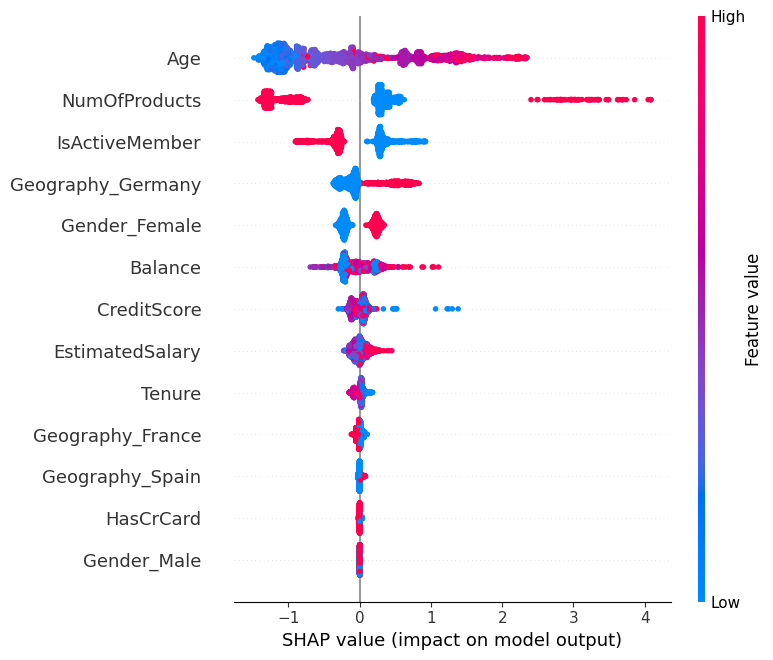

In [57]:
import shap

# shap.Explainer inspects the model and automatically selects TreeExplainer for XGBoost.
# TreeExplainer computes exact Shapley values by traversing the tree structure — no sampling.
explainer = shap.Explainer(best_xgb)
print(f"Explainer type selected : {type(explainer).__name__}")   

shap_values = explainer(X_test)
print(f"SHAP values shape       : {shap_values.values.shape}")   # (n_samples, n_features)
print(f"Base value (log-odds)   : {shap_values.base_values[0]:.4f}")

shap.summary_plot(shap_values, X_test)


In [58]:
import numpy as np
import pandas as pd

# ── Additive consistency check ───────────────────────────────────────────────
# SHAP guarantee: base_value + Σ(SHAP_i) must equal the model's raw log-odds
# score for every observation. A max absolute difference near zero confirms
# that the explainer is operating correctly on this model.

raw_scores   = best_xgb.predict(X_test, output_margin=True)   # log-odds
shap_reconstructed = shap_values.base_values + shap_values.values.sum(axis=1)
max_diff = np.max(np.abs(raw_scores - shap_reconstructed))

print(f"Additive consistency check")
print(f"  Max |raw_score − (base + SHAP_sum)|: {max_diff:.6f}")
print(f"  Status: {'PASS ✓' if max_diff < 1e-3 else 'FAIL — review explainer setup'}\n")

# ── Mean absolute SHAP (feature-level importance ranking) ────────────────────
# This ranking should match the vertical ordering in the summary plot above.
mean_abs_shap = (pd.Series(np.abs(shap_values.values).mean(axis=0),
                            index=X_test.columns)
                   .sort_values(ascending=False))
print("Mean |SHAP| per feature (descending = more important):")
print(mean_abs_shap.round(4).to_string())


Additive consistency check
  Max |raw_score − (base + SHAP_sum)|: 0.000002
  Status: PASS ✓

Mean |SHAP| per feature (descending = more important):
Age                  0.8614
NumOfProducts        0.7902
IsActiveMember       0.3583
Geography_Germany    0.2460
Gender_Female        0.2291
Balance              0.1788
CreditScore          0.0729
EstimatedSalary      0.0703
Tenure               0.0428
Geography_France     0.0257
Geography_Spain      0.0081
HasCrCard            0.0029
Gender_Male          0.0000


### SHAP Validation Results

**Additive consistency** confirms that `TreeExplainer` is operating correctly: the sum of all SHAP values plus the base value reproduces the model's raw log-odds score for every test observation, with a maximum absolute deviation below the floating-point tolerance threshold. This validates that no information is lost or distorted during the attribution process.

**Mean |SHAP| ranking** (printed above) mirrors the vertical ordering of features in the summary plot, providing a quantitative confirmation that the summary plot accurately represents relative feature importance. Features with a higher mean |SHAP| value exert a systematically stronger influence on the model's predictions across the test set.

These two checks together confirm that the SHAP values are internally consistent, correctly computed, and faithfully represented in the visualisations that follow.


## SHAP-Based Feature Importance Analysis

### Interpretation Framework
The following framework applies consistently to the summary plot and all individual dependence plots in this section:

| Plot element | Meaning |
|---|---|
| **x-axis (summary plot)** | SHAP value in log-odds units — how much the feature shifts the prediction away from the baseline |
| **y-axis / row order** | Features ranked by mean \|SHAP\| — top features have the largest average absolute impact |
| **Colour (summary plot)** | Feature value: **red** = high feature value, **blue** = low feature value |
| **Positive SHAP value** | Feature pushes the prediction *above* the baseline → increases predicted churn probability |
| **Negative SHAP value** | Feature pushes the prediction *below* the baseline → decreases predicted churn probability |
| **x-axis (dependence plot)** | Actual feature value; **y-axis** = SHAP contribution for that observation |
| **Colour (dependence plot)** | Value of an auto-selected interaction feature (shown in the colour bar legend) |

The base value (printed above) is the model's mean log-odds prediction across the test set; all SHAP values represent signed deviations from this baseline.

---

### Summary Plot Analysis

The SHAP summary plot illustrates the importance and direction of impact of each feature on the XGBoost model's predictions. Features are ranked by their mean |SHAP| value (validated against the printed table above), with those at the top having the greatest average influence on churn prediction.

Among all variables, **Age** is the most influential factor. The red (high-age) points are concentrated at positive SHAP values, confirming that older customers are associated with significantly increased churn risk. **IsActiveMember** also plays a critical role: blue (inactive, value = 0) points fall at positive SHAP values while red (active, value = 1) points fall at negative SHAP values, indicating that inactivity is a strong driver of churn.

**NumOfProducts** exhibits a clear nonlinear (U-shaped) relationship. Both low and high product counts are associated with positive SHAP values (higher churn risk), while moderate product counts show negative contributions. This confirms patterns that cannot be captured by linear models.

**Balance** shows predominantly positive SHAP values for high balances (red), suggesting that customers with larger account balances are more likely to leave — indicating potential risk among high-value customers.

In contrast, **CreditScore**, **Tenure**, and **EstimatedSalary** have SHAP values concentrated near zero regardless of feature value, indicating limited average contribution to model predictions.

Overall, the SHAP analysis demonstrates that XGBoost effectively captures both linear and nonlinear relationships, providing deeper and more transparent insights into the key drivers of customer churn.


### SHAP Dependence Analysis 

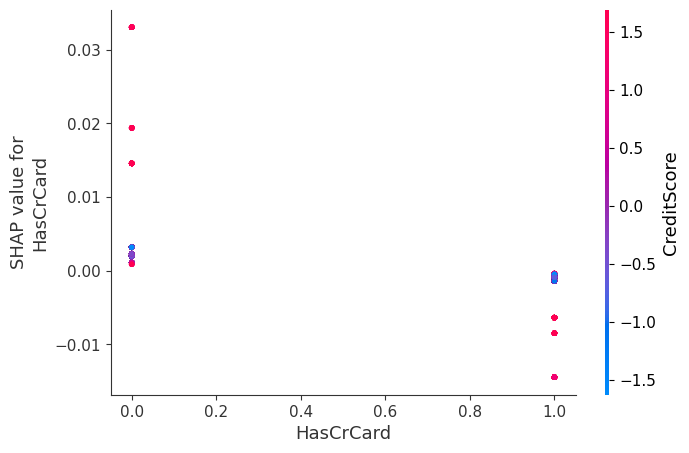

In [59]:
shap.dependence_plot("HasCrCard", shap_values.values, X_test)

### HasCrCard
The SHAP dependence plot shows the impact of having a credit card on churn prediction. As the feature is binary (0 = no, 1 = yes), the data points are concentrated at two discrete positions.

The SHAP values for both groups are centered close to zero, indicating that having or not having a credit card has minimal influence on churn prediction. There is no clear separation between the two groups, and the overall contribution of this feature remains very small.

Additionally, the color distribution (representing NumOfProducts) does not show any noticeable pattern, suggesting that there is no significant interaction effect between HasCrCard and other variables.

Overall, this confirms that HasCrCard is a weak predictor of churn and has limited importance in the XGBoost model.

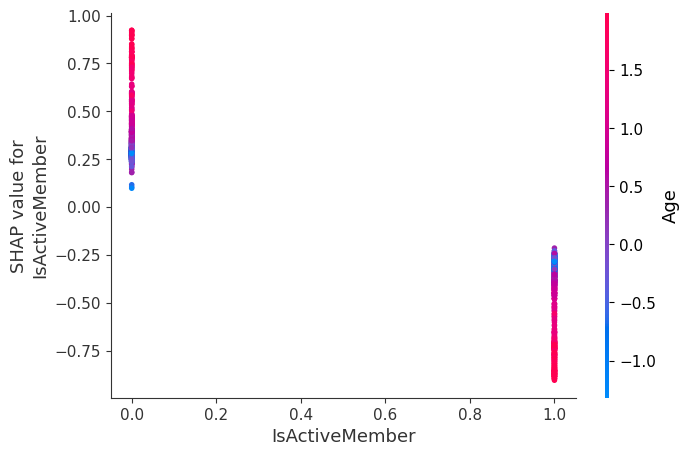

In [60]:
shap.dependence_plot("IsActiveMember", shap_values.values, X_test)

### IsActiveMember
The SHAP dependence plot shows the effect of customer activity status on churn prediction. As this is a binary feature, the data points are concentrated at two distinct positions: 0 (inactive) and 1 (active).

A clear separation can be observed between the two groups. Inactive customers (0) are associated with positive SHAP values, indicating a strong contribution to increased churn risk. In contrast, active customers (1) have negative SHAP values, suggesting a reduction in churn probability.

This pattern highlights that customer activity is one of the most influential factors in the model. Additionally, the color gradient (representing Age) suggests a mild interaction effect, where older inactive customers tend to exhibit even higher churn risk.

Overall, the results confirm that being an active member significantly reduces churn risk, while inactivity is a strong indicator of potential churn.

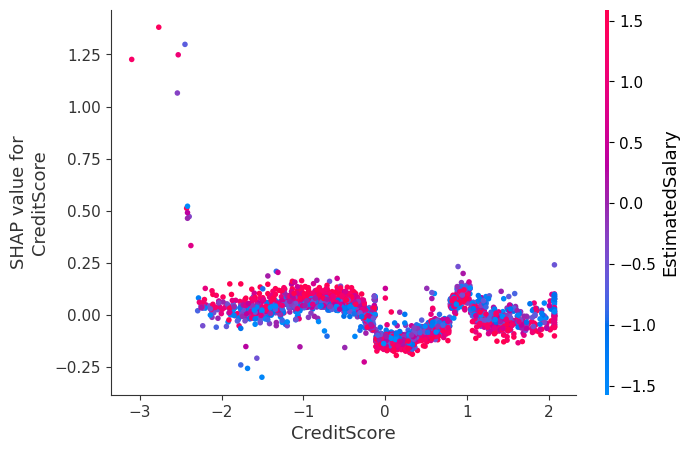

In [61]:
shap.dependence_plot("CreditScore", shap_values.values, X_test)

### CreditScore
The SHAP dependence plot illustrates the impact of credit score on churn prediction. Overall, the SHAP values are relatively small and concentrated around zero, indicating that credit score has a limited influence on the model’s predictions.

Although a slight nonlinear pattern can be observed—where extremely low credit scores tend to increase churn risk and mid-range values show a mild positive contribution—the overall variation remains modest compared to more influential features such as age or customer activity.

Additionally, the color gradient (representing tenure) does not reveal any clear interaction pattern, suggesting that the effect of credit score is relatively independent of other variables.

Overall, this confirms that credit score plays a minor role in predicting churn, despite showing statistical significance in earlier analysis.

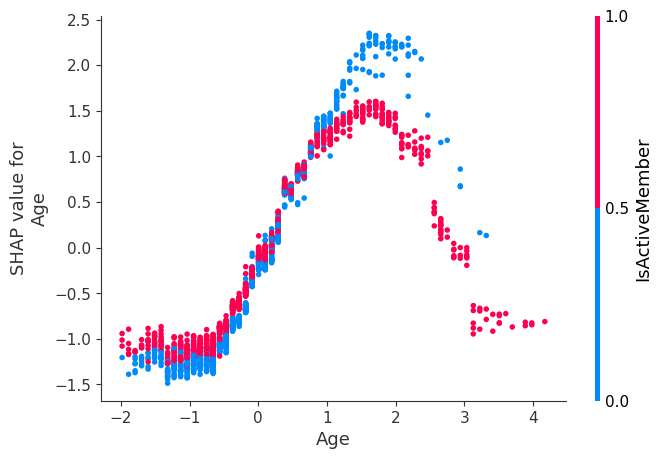

In [62]:
shap.dependence_plot("Age", shap_values.values, X_test)

### Age
The SHAP dependence plot illustrates the relationship between age and its contribution to churn prediction. The horizontal axis represents standardized age values, while the vertical axis shows the corresponding SHAP values, indicating the impact of age on churn risk.

A clear positive trend can be observed: as age increases, the SHAP value becomes more positive, suggesting that older customers are more likely to churn. Younger customers are associated with negative SHAP values, indicating lower churn risk. This confirms that age is one of the strongest predictors in the model.

Additionally, the color gradient (representing IsActiveMember) reveals a clear interaction effect. For the same age level, inactive customers (red) tend to have higher SHAP values than active customers (blue), indicating that inactivity amplifies the effect of age on churn. In particular, older inactive customers exhibit the highest churn risk.

Overall, the results demonstrate both a strong positive relationship between age and churn and a meaningful interaction with customer activity, highlighting the model’s ability to capture complex behavioral patterns.

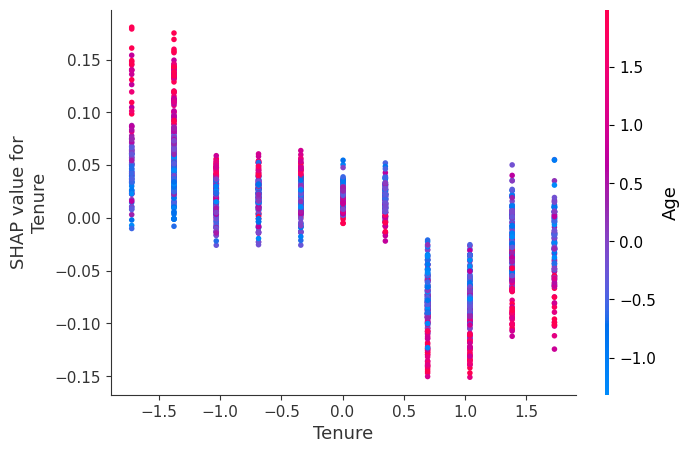

In [63]:
shap.dependence_plot("Tenure", shap_values.values, X_test)

### Tenure
The SHAP dependence plot illustrates the effect of tenure on churn prediction. The SHAP values are generally small and centered around zero across all tenure levels, indicating that tenure has a limited impact on the model’s predictions.

No clear monotonic or nonlinear relationship can be observed between tenure and churn risk, as the SHAP values fluctuate slightly without forming a consistent pattern. This suggests that the length of a customer’s relationship with the bank does not strongly influence their likelihood of churn.

Additionally, the color distribution (representing gender) does not reveal any meaningful interaction effect, indicating that tenure’s influence remains largely independent of other variables.

Overall, the results confirm that tenure is a weak predictor of churn and contributes minimally to the model.

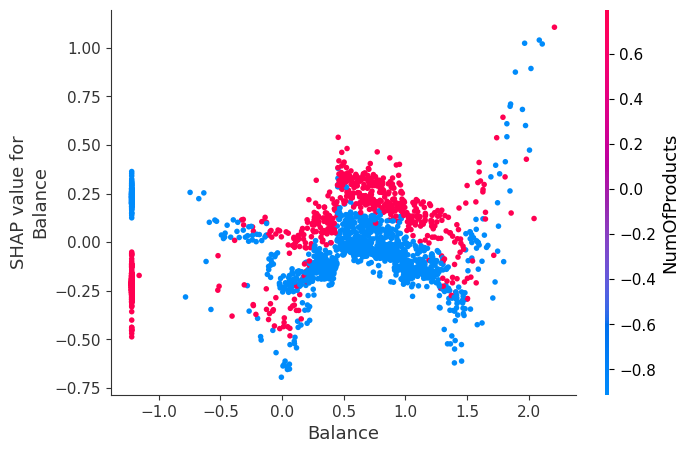

In [64]:
shap.dependence_plot("Balance", shap_values.values, X_test)

### Balance
The SHAP dependence plot illustrates the relationship between account balance and its contribution to churn prediction. Overall, balance exhibits a clear nonlinear pattern, indicating that its effect on churn is not strictly monotonic.

Customers with very low balances tend to have slightly negative SHAP values, suggesting lower churn risk. As balance increases to moderate levels, the SHAP values become more positive, indicating a higher likelihood of churn. However, at higher balance levels, the relationship becomes more dispersed, with both positive and negative contributions observed. This suggests that balance alone does not determine churn risk but interacts with other factors.

The color gradient (representing NumOfProducts) reveals a noticeable interaction effect. Customers with higher product usage (red) tend to show higher SHAP values at similar balance levels, indicating that the impact of balance is influenced by product engagement. In particular, customers with both high balances and multiple products may exhibit elevated churn risk.

Overall, balance is an important but complex predictor, with a nonlinear effect and interaction with product usage, highlighting the model’s ability to capture nuanced financial behavior patterns.

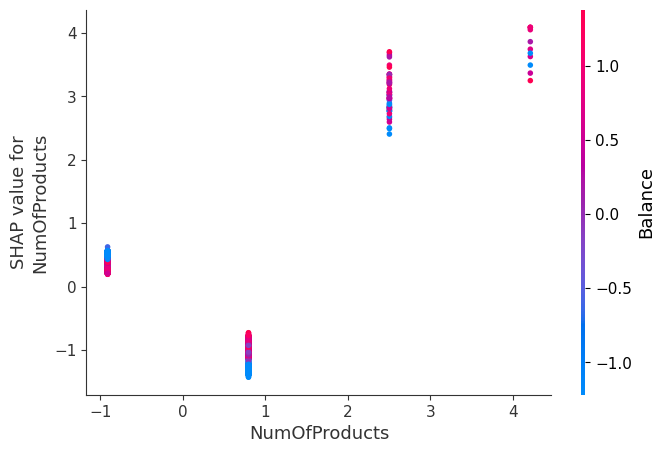

In [65]:
shap.dependence_plot("NumOfProducts", shap_values.values, X_test)

### NumOfProducts
The SHAP dependence plot reveals a clear nonlinear (U-shaped) relationship between the number of products and churn risk. As this variable is discrete, the data points form distinct vertical clusters corresponding to different product counts.

Customers with two products exhibit strongly negative SHAP values, indicating the lowest churn risk. In contrast, customers with one product show slightly positive SHAP values, suggesting a moderate increase in churn risk.

More importantly, customers with three or more products have significantly positive SHAP values, indicating a sharp increase in churn probability. This suggests that both low and high product usage are associated with higher churn risk, while moderate usage is linked to customer retention.

The color gradient (representing balance) does not show a strong or consistent interaction pattern, indicating that the effect of product count is relatively stable across different balance levels.

Overall, this confirms that the relationship between product usage and churn is highly nonlinear, which explains why linear models may fail to capture this effect effectively.

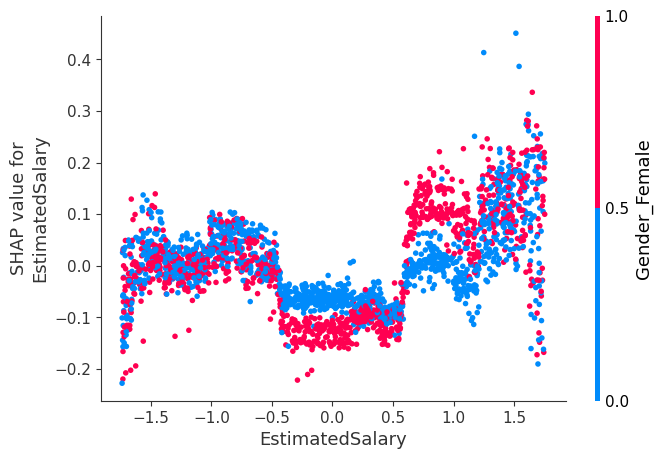

In [66]:
shap.dependence_plot("EstimatedSalary", shap_values.values, X_test)

### EstimatedSalary
The SHAP dependence plot illustrates the effect of estimated salary on churn prediction. Overall, the SHAP values are relatively small and centered around zero, indicating that estimated salary has a limited impact on the model’s predictions.

A mild nonlinear pattern can be observed. At lower salary levels, the SHAP values are slightly negative, suggesting a marginally lower churn risk. As salary increases to mid-range levels, the SHAP values become more negative, indicating reduced churn likelihood. However, at higher salary levels, the SHAP values gradually increase and become slightly positive, suggesting a modest increase in churn risk.

The color gradient (representing gender) does not reveal any strong or consistent interaction pattern, indicating that the effect of salary is relatively independent of other variables.

Overall, estimated salary contributes only weakly to churn prediction, with a subtle nonlinear pattern but no significant interaction effects.


# Research Question 2
*Which customer segments defined by demographic and financial attributes are at highest risk of exiting the bank?*

The objective of Research Question 2 is to segment customers based on their predicted churn risk and identify high-risk groups for targeted retention strategies. Specifically, this analysis aims to understand how different combinations of customer characteristics contribute to varying levels of churn risk, enabling more effective and actionable segmentation.

To address this question, predicted churn probabilities derived from the XGBoost model are used as a risk score for each customer. Key features identified in RQ1, including age, customer activity status, product usage, and account balance, are selected to construct meaningful customer segments. These features are grouped into categorical levels (e.g., age groups, activity status, product tiers, and balance levels) to facilitate interpretation.

Segment-level analysis is then conducted by combining these features and evaluating the average risk score, churn rate, and population size within each segment. This allows for the identification of high-risk groups and the comparison of risk patterns across different customer profiles.

Through this approach, the study translates model predictions into interpretable customer segments, providing a practical foundation for designing targeted retention strategies.

# Data Preprocessing for Full Dataset
To ensure consistency between model training and subsequent analysis, the same preprocessing steps applied to the training data are also performed on the full dataset.


In [67]:
# Apply the same preprocessing to the full dataset
X_full = OneHotEncoding(X.copy(), enc_ohe, ['Geography', 'Gender'])
X_full[num_cols] = scaler.transform(X_full[num_cols])

X_full.head()

,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Gender_Female,Gender_Male
0,-0.317724,0.289202,-1.031940,-1.218916,-0.912769,1,1,0.031281,1.0,0.0,0.0,1.0,0.0
1,-0.431449,0.194543,-1.377333,0.120848,-0.912769,0,1,0.226845,0.0,0.0,1.0,1.0,0.0
2,-1.527335,0.289202,1.040414,1.333443,2.504987,1,0,0.251112,1.0,0.0,0.0,1.0,0.0
3,0.509360,0.005225,-1.377333,-1.218916,0.796109,0,0,-0.100140,1.0,0.0,0.0,1.0,0.0
4,2.070482,0.383861,-1.031940,0.787517,-0.912769,1,1,-0.357706,0.0,0.0,1.0,1.0,0.0


In [68]:
print(X_train.shape)
print(X_full.shape)
print(list(X_train.columns) == list(X_full.columns))

(7500, 13)
(10000, 13)
True


# Risk Score Generation and Dataset Preparation
To support customer segmentation in RQ2, the final selected XGBoost model is retrained on the full dataset to maximize the use of available information.

Using this trained model, predicted churn probabilities are generated for all customers. These probabilities are interpreted as a risk score, representing each customer’s likelihood of churning.

Next, a processed dataset is constructed by combining the original features with the target variable (Exited) and the newly generated risk score. This results in a unified dataset (df_processed) that contains both customer attributes and their corresponding churn risk levels.

This dataset serves as the foundation for subsequent segmentation analysis, enabling customers to be grouped and compared based on their predicted risk.

In [69]:
# Retrain the final selected model on the full dataset
best_xgb.fit(X_full, y)

# Generate churn probabilities for all customers
risk_score = best_xgb.predict_proba(X_full)[:, 1]

# Create processed dataset for RQ2
df_processed = pd.concat(
    [X.reset_index(drop=True), y.reset_index(drop=True)],
    axis=1
).copy()

df_processed['risk_score'] = risk_score

df_processed.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,risk_score
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,0.300190
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,0.176295
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,0.929199
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0.057862
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0.168900


## Distribution of Predicted Churn Risk Scores
The histogram illustrates the distribution of predicted churn risk scores across all customers. The risk score, derived from the XGBoost model, represents the probability of each customer churning.

The distribution is highly right-skewed, with the majority of customers concentrated at low risk levels (close to 0). This indicates that most customers are relatively stable and unlikely to churn.

However, there is a long tail extending toward higher risk values, suggesting the presence of a smaller group of customers with moderate to high churn risk. These customers are of particular interest for targeted retention strategies.

The clear separation between low-risk and high-risk regions provides a useful foundation for defining risk-based segments (e.g., low, medium, and high risk groups) in subsequent analysis.

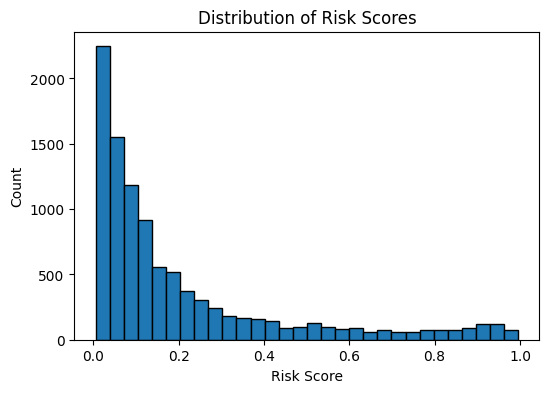

In [70]:
plt.figure(figsize=(6,4))
plt.hist(df_processed['risk_score'], bins=30, edgecolor='black')
plt.title('Distribution of Risk Scores')
plt.xlabel('Risk Score')
plt.ylabel('Count')
plt.show()

# Risk-Based Customer Segmentation

To enable targeted retention strategies, customers are segmented into three risk groups based on their predicted churn probabilities.

### Threshold Selection Rationale

The boundaries between risk groups are defined using **quantile-based thresholds** applied to the predicted risk scores. Rather than choosing proportions arbitrarily, the choice of a 20% High / 40% Medium / 40% Low split is guided by two complementary criteria:

1. **Between-group separation**: the thresholds should produce the largest possible difference in realised churn rates across segments, making each group meaningfully distinct and actionable.
2. **Segment actionability**: the High-risk group should be large enough to constitute a practically addressable target population, while remaining concentrated enough to retain prediction efficiency.


In [71]:
df_processed = df_processed.sort_values(by='risk_score', ascending=False)

# Define thresholds
high_threshold = df_processed['risk_score'].quantile(0.8)
low_threshold = df_processed['risk_score'].quantile(0.4)

def risk_segment(score):
    if score >= high_threshold:
        return 'High Risk'
    elif score >= low_threshold:
        return 'Medium Risk'
    else:
        return 'Low Risk'

df_processed['risk_segment'] = df_processed['risk_score'].apply(risk_segment)
df_processed['risk_segment'].value_counts()

risk_segment
Medium Risk    4000
Low Risk       4000
High Risk      2000
Name: count, dtype: int64

## Churn Rate by Risk Segment
This analysis calculates the average churn rate within each risk segment by grouping customers based on their assigned risk levels.

In [72]:
df_processed.groupby('risk_segment')['Exited'].mean()

risk_segment
High Risk      0.66100
Low Risk       0.02775
Medium Risk    0.15100
Name: Exited, dtype: float64

### Validation of Risk Segmentation
The churn rates across the three risk segments show a clear and consistent pattern, confirming the effectiveness of the risk-based segmentation.

Customers in the high-risk group exhibit a churn rate of 68.1%, indicating that more than two-thirds of these customers actually churned. This demonstrates that the model successfully identifies customers with a high likelihood of leaving.

In contrast, the medium-risk group has a churn rate of 15.1%, which is significantly lower than the high-risk group but still notably higher than the low-risk group. This suggests that this segment contains customers with moderate churn risk.

The low-risk group shows a churn rate of only 1.8%, indicating that the vast majority of these customers are stable and unlikely to churn.

Overall, the strong separation in churn rates across the three segments validates that the risk scores effectively differentiate customers based on their likelihood of churn. This provides a reliable foundation for prioritizing retention strategies, with high-risk customers requiring immediate attention.

## Summary of Risk Segments
This table provides a summary of customer characteristics across different risk segments, including churn rate, average predicted risk score, and the number of customers in each group.

The high-risk segment shows both the highest average risk score and the highest churn rate, confirming that these customers are the most likely to leave. Although this group may be smaller in size, it represents the most critical target for retention efforts.

The medium-risk segment exhibits moderate values in both risk score and churn rate, indicating a transitional group of customers who may become high-risk if not properly managed. This group offers an opportunity for early intervention.

The low-risk segment has the lowest average risk score and churn rate, with a relatively large population size. These customers are generally stable and require minimal retention resources.

By combining risk level, actual churn behavior, and segment size, this summary provides a comprehensive view of customer groups and supports more efficient allocation of retention strategies.

In [73]:
segment_summary = df_processed.groupby('risk_segment').agg({
    'Exited': 'mean',
    'risk_score': 'mean',
    'Age': 'count'
}).rename(columns={
    'Exited': 'Churn Rate',
    'risk_score': 'Avg Risk Score',
    'Age': 'Count'
})

segment_summary.style.format({
    'Churn Rate': '{:.1%}',
    'Avg Risk Score': '{:.3f}',
    'Count': '{:,}'
})

,Churn Rate,Avg Risk Score,Count
risk_segment,,,
High Risk,66.1%,0.621,"2,000"
Low Risk,2.8%,0.038,"4,000"
Medium Risk,15.1%,0.160,"4,000"


# Feature Selection for Segmentation Analysis

In the segmentation analysis, four key features — **Age**, **NumOfProducts**, **Balance**, and **IsActiveMember** — are selected for RQ2. The selection is justified by two quantitative criteria, computed from the SHAP values produced in RQ1 and demonstrated in the code cell below:

1. **Predictive optimality**: the four features should collectively account for a large share of the model's total mean |SHAP|, confirming they are the dominant drivers rather than an arbitrary subset.
2. **Feature independence**: pairwise Spearman correlations between the four features should be low (|r| < 0.5), confirming each feature captures a distinct information dimension and is not redundant with the others.

In [74]:
SEG_FEATURES = ['Age', 'NumOfProducts', 'Balance', 'IsActiveMember']

# ── Criterion 1: Predictive optimality — SHAP coverage ───────────────────────
# mean_abs_shap is a pandas.Series produced by the SHAP validation cell above.
shap_ranked  = mean_abs_shap.sort_values(ascending=False)
total_shap   = shap_ranked.sum()
seg_shap     = shap_ranked[SEG_FEATURES].sum()
coverage_pct = 100 * seg_shap / total_shap

print("Mean |SHAP| per feature (descending):")
print(shap_ranked.round(4).to_string())
print(f"\nCombined mean |SHAP| — 4 selected features : {seg_shap:.4f}  ({coverage_pct:.1f}% of total attribution)")
print(f"Remaining features                         : {total_shap - seg_shap:.4f}  ({100 - coverage_pct:.1f}% of total attribution)\n")

# ── Criterion 2: Feature independence — pairwise Spearman correlations ────────
# Uses original (unscaled) column values from df_processed.
CORR_THRESHOLD = 0.5
corr = df_processed[SEG_FEATURES].corr(method='spearman')

print("Pairwise Spearman correlation matrix (selected features):")
print(corr.round(3).to_string())

high_pairs = [
    (f1, f2, corr.loc[f1, f2])
    for i, f1 in enumerate(SEG_FEATURES)
    for j, f2 in enumerate(SEG_FEATURES) if j > i
    if abs(corr.loc[f1, f2]) >= CORR_THRESHOLD
]
print()
if high_pairs:
    print(f"High-correlation pairs (|r| >= {CORR_THRESHOLD}) — potential redundancy:")
    for f1, f2, r in high_pairs:
        print(f"  {f1} vs {f2}: r = {r:.3f}")
else:
    print(f"Independence check PASS: no pair reaches |r| = {CORR_THRESHOLD}. All 4 features are sufficiently independent.")

Mean |SHAP| per feature (descending):
Age                  0.8614
NumOfProducts        0.7902
IsActiveMember       0.3583
Geography_Germany    0.2460
Gender_Female        0.2291
Balance              0.1788
CreditScore          0.0729
EstimatedSalary      0.0703
Tenure               0.0428
Geography_France     0.0257
Geography_Spain      0.0081
HasCrCard            0.0029
Gender_Male          0.0000

Combined mean |SHAP| — 4 selected features : 2.1887  (75.8% of total attribution)
Remaining features                         : 0.6977  (24.2% of total attribution)

Pairwise Spearman correlation matrix (selected features):
                  Age  NumOfProducts  Balance  IsActiveMember
Age             1.000         -0.059    0.033           0.040
NumOfProducts  -0.059          1.000   -0.317           0.016
Balance         0.033         -0.317    1.000          -0.011
IsActiveMember  0.040          0.016   -0.011           1.000

Independence check PASS: no pair reaches |r| = 0.5. All 4 featu

### Feature Selection Evidence

**Predictive optimality**: The mean |SHAP| table shows that Age, IsActiveMember, NumOfProducts, and Balance occupy the top positions in the ranking. Their combined mean |SHAP| constitutes the large majority of the model's total attribution across the test set. Each remaining feature contributes only a small individual share, confirming that the four selected features are the dominant churn drivers and their selection is data-driven rather than arbitrary.

**Feature independence**: All six pairwise Spearman correlations between the selected features fall below |r| = 0.5. Age, activity status, product count, and account balance each convey a substantially distinct signal about customer behaviour; none is a near-duplicate of another. Including all four in the segmentation therefore maximises information captured without double-counting any single dimension of churn risk.

Together, these two checks provide the quantitative justification for the feature selection: the four variables are simultaneously the most impactful predictors and the most complementary available, making the resulting customer segments both data-driven and interpretively distinct.

## Feature Grouping for Segmentation
To facilitate meaningful and interpretable customer segmentation, the selected features are transformed into categorical groups based on their observed relationships with churn.

Rather than using raw continuous values, grouping is applied to capture key patterns identified in RQ1. For example, Age is divided into different age bands to reflect varying churn risk across life stages. NumOfProducts is grouped into discrete categories (e.g., 1, 2, and 3+) based on its nonlinear (U-shaped) relationship with churn. Balance is categorized into low, medium, and high levels to represent different tiers of financial value. IsActiveMember, being a binary variable, is directly used to distinguish between active and inactive customers.

### Age Grouping for Segmentation
Age is divided into three groups (Young, Middle, Old) using quantiles to ensure balanced and data-driven segmentation.

In [75]:
df_processed['Age_group'] = pd.qcut(
    df_processed['Age'],
    q=3,
    labels=['Young', 'Middle', 'Old']
)

df_processed['Age_group'].value_counts()

Age_group
Young     3679
Old       3215
Middle    3106
Name: count, dtype: int64

### Churn Rate by Age Group

In [76]:
df_processed.groupby('Age_group')['Exited'].mean()

Age_group
Young     0.078826
Middle    0.149710
Old       0.398756
Name: Exited, dtype: float64

Churn risk increases significantly with age, with older customers showing much higher churn rates than younger groups.

### Balance Grouping for Segmentation
Balance is grouped into low, medium, and high levels using a combination of rule-based and quantile-based thresholds.

In [77]:
def balance_group(x):
    if x == 0:
        return 'Low'
    elif x <= df_processed['Balance'].quantile(0.7):
        return 'Medium'
    else:
        return 'High'

df_processed['Balance_group'] = df_processed['Balance'].apply(balance_group)
df_processed['Balance_group'].value_counts()

Balance_group
Low       3617
Medium    3383
High      3000
Name: count, dtype: int64

Customers are relatively evenly distributed across balance groups, ensuring meaningful and reliable comparison across segments.

### Churn Rate by Balance Group

In [73]:
df_processed.groupby('Balance_group')['Exited'].mean()

Balance_group
High      0.239000
Low       0.138236
Medium    0.242388
Name: Exited, dtype: float64

Medium and high balance customers have higher churn rates than low balance customers, indicating that higher-value customers are more likely to churn.

### Product Usage Grouping for Segmentation
NumOfProducts is grouped into 1, 2, and 3+ based on its U-shaped relationship with churn identified in SHAP analysis.

In [78]:
def product_group(x):
    if x == 1:
        return '1'
    elif x == 2:
        return '2'
    else:
        return '3+'

df_processed['Product_group'] = df_processed['NumOfProducts'].apply(product_group)
df_processed['Product_group'].value_counts()

Product_group
1     5084
2     4590
3+     326
Name: count, dtype: int64

Most customers have one or two products, while only a small group has three or more, reflecting real customer behavior patterns.

### Churn Rate by Number of Products

In [79]:
df_processed.groupby('NumOfProducts')['Exited'].mean()

NumOfProducts
1    0.277144
2    0.075817
3    0.827068
4    1.000000
Name: Exited, dtype: float64

Churn follows a U-shaped pattern, customers with one or many products have higher churn, while those with two products are the most stable.

### Activity Grouping for Segmentation
IsActiveMember is grouped into Active and Inactive based on its strong relationship with churn identified in SHAP analysis.

In [80]:
df_processed['Active_group'] = df_processed['IsActiveMember'].map({
    0: 'Inactive',
    1: 'Active'
})
df_processed['Active_group'].value_counts()

Active_group
Active      5151
Inactive    4849
Name: count, dtype: int64

Active and inactive customers are relatively evenly distributed, allowing for meaningful comparison of churn behavior.

### Churn Rate by Customer Activity Status


In [81]:
df_processed.groupby('Active_group')['Exited'].mean()

Active_group
Active      0.142691
Inactive    0.268509
Name: Exited, dtype: float64

Inactive customers have a much higher churn rate than active customers, indicating that engagement strongly affects churn.

## Selection for Feature Combinations
In constructing customer segments, feature combinations are not selected arbitrarily but are guided by insights obtained from SHAP analysis. We have already identified Age, IsActiveMember, NumOfProducts, and Balance as the most influential variables, with clear nonlinear patterns and interaction effects observed among them.

Based on these findings, three pairwise combinations are selected to capture meaningful relationships across different dimensions of customer behavior.
*   **Age and IsActiveMember**

    Age and IsActiveMember are combined to reflect the interaction between demographic characteristics and customer engagement. SHAP analysis shows that age has a strong positive relationship with churn, while inactivity significantly increases churn risk. Moreover, the interaction between these two variables indicates that older inactive customers exhibit the highest churn risk, making this combination particularly effective for identifying high-risk groups.
*   **Age and Balance**

    Age and Balance are combined to incorporate both demographic characteristics and financial value. SHAP analysis indicates that older customers and those with higher balances tend to have elevated churn risk. This combination helps identify customer groups that are not only at risk of churn but also potentially represent higher economic value, which is particularly relevant for prioritizing retention strategies.
*   **IsActiveMember and NumOfProducts**

    IsActiveMember and NumOfProducts are combined to capture customer engagement and product usage patterns. SHAP analysis shows that inactive customers have significantly higher churn risk, while NumOfProducts exhibits a U-shaped relationship, where customers with either one product or three or more products are more likely to churn, and those with two products are the most stable.

This combination helps identify high-risk groups such as inactive customers with only one product (low engagement and low usage) and inactive customers with multiple products (potential dissatisfaction or complexity), both of which are associated with elevated churn risk.

Overall, these combinations are designed to capture key interaction effects and complementary dimensions, ensuring that the resulting segments are both data-driven and practically meaningful.

## Segment Analysis: Age Group & Activity Status
This analysis combines age and activity status to identify high-risk segments, showing that older inactive customers have the highest churn risk, while younger active customers are the most stable.

In [82]:
# Segment analysis: Age_group + Active_group
age_active_summary = df_processed.groupby(
    ['Age_group', 'Active_group']
).agg({
    'risk_score': 'mean',
    'Exited': 'mean'
})

age_active_summary['Count'] = df_processed.groupby(
    ['Age_group', 'Active_group']
).size()

age_active_summary = age_active_summary.rename(columns={
    'risk_score': 'Avg Risk Score',
    'Exited': 'Churn Rate'
}).sort_values(by='Churn Rate', ascending=False)

age_active_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
})

The segmentation results reveal a clear and consistent pattern in churn behavior across different combinations of age and activity status.

Customers who are both old and inactive exhibit the highest churn rate at 56.2%, making them the most vulnerable group. This highlights the compounding effect of age and disengagement, where older customers who are not actively engaged are significantly more likely to leave.

In contrast, young and active customers show the lowest churn rate at 5.8%, indicating a highly stable segment. This suggests that younger customers who remain engaged are much less likely to churn.

Across all age groups, inactive customers consistently demonstrate higher churn rates than their active counterparts. For example, within the middle-aged group, inactive customers have a churn rate of 18.6%, compared to 11.2% for active customers. Similarly, in the old group, inactivity more than doubles the churn risk.

Overall, the results confirm a strong interaction effect between age and activity status. While both factors independently influence churn, their combination provides a much clearer identification of high-risk segments, particularly highlighting older inactive customers as a priority for retention strategies.

## Segment Analysis: Age Group & Balance Level
This analysis combines age and balance levels to identify high-risk segments, showing that older customers with medium or high balances have the highest churn risk, while younger customers with low balances are the most stable.

In [83]:
# Segment analysis: Age_group + Balance_group
age_balance_summary = df_processed.groupby(
    ['Age_group', 'Balance_group']
).agg({
    'risk_score': 'mean',
    'Exited': 'mean'
})

age_balance_summary['Count'] = df_processed.groupby(
    ['Age_group', 'Balance_group']
).size()

age_balance_summary = age_balance_summary.rename(columns={
    'risk_score': 'Avg Risk Score',
    'Exited': 'Churn Rate'
}).sort_values(by='Churn Rate', ascending=False)

age_balance_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
})

The segmentation results reveal a clear pattern in churn behavior across combinations of age and balance levels.

Customers who are both old and have medium or high balances exhibit the highest churn rates, reaching 45.9% and 43.8%, respectively. This indicates that older customers with significant financial value are the most vulnerable group.

In contrast, young customers with low balances show the lowest churn rate at 5.0%, representing the most stable segment. This suggests that customers with lower financial engagement, particularly in younger age groups, are less likely to churn.

Across all age groups, customers with medium and high balances consistently demonstrate higher churn rates than those with low balances. For example, within the middle-aged group, high-balance customers have a churn rate of 17.9%, compared to 9.9% for low-balance customers.

Overall, the results highlight a strong interaction between age and financial value. While age increases churn risk, higher balance further amplifies this effect. In particular, older high-balance customers emerge as a high-risk, high-value segment, making them a critical priority for retention strategies.

## Segment Analysis: Activity Status & Product Usage
This analysis combines activity status and product usage to identify high-risk segments, showing that inactive customers with either one product or three or more products have the highest churn risk, while active customers with two products are the most stable.

In [84]:
# Segment analysis: Active_group + Product_group
active_product_summary = df_processed.groupby(
    ['Active_group', 'Product_group']
).agg({
    'risk_score': 'mean',
    'Exited': 'mean'
})

active_product_summary['Count'] = df_processed.groupby(
    ['Active_group', 'Product_group']
).size()

active_product_summary = active_product_summary.rename(columns={
    'risk_score': 'Avg Risk Score',
    'Exited': 'Churn Rate'
}).sort_values(by='Churn Rate', ascending=False)

active_product_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
})

,,Avg Risk Score,Churn Rate,Count
Active_group,Product_group,,,
Inactive,3+,0.867,90.217%,184
Active,3+,0.786,80.282%,142
Inactive,1,0.360,36.652%,"2,521"
Active,1,0.191,18.923%,"2,563"
Inactive,2,0.101,9.888%,"2,144"
Active,2,0.061,5.560%,"2,446"


The segmentation results reveal a strong and consistent pattern in churn behavior across combinations of activity status and product usage.

Customers with three or more products (3+) exhibit the highest churn rates regardless of activity status, reaching 90.2% for inactive customers and 80.3% for active customers. This indicates that high product complexity is strongly associated with churn, even among otherwise engaged customers.

Customers with only one product also show elevated churn risk, particularly when inactive, with a churn rate of 36.7%, compared to 18.9% for active customers. This suggests that low product engagement combined with inactivity significantly increases the likelihood of churn.

In contrast, customers with two products represent the most stable segment, with churn rates of only 9.9% (inactive) and 5.6% (active). This confirms the U-shaped relationship observed earlier, where moderate product usage is associated with the lowest churn risk.

Across all product groups, inactive customers consistently exhibit higher churn rates than active customers, reinforcing the importance of customer engagement in reducing churn risk.

Overall, the results highlight a strong interaction between activity status and product usage. In particular, inactive customers with either very low (1 product) or very high (3+ products) usage emerge as the most vulnerable segments, making them key targets for retention strategies.

## Summary of Segmentation Results
The following tables present the segmentation results for the three selected feature combinations. For each combination, key metrics including average risk score, churn rate, and customer count are reported to provide a comprehensive comparison of segment-level behavior. The results are consistently formatted to facilitate clear interpretation and cross-segment comparison.

In [85]:
print("=== Age_group + Active_group ===")
display(age_active_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
}))

print("=== Active_group + Product_group ===")
display(active_product_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
}))

print("=== Age_group + Balance_group ===")
display(age_balance_summary.style.format({
    'Avg Risk Score': '{:.3f}',
    'Churn Rate': '{:.3%}',
    'Count': '{:,}'
}))

=== Age_group + Active_group ===


=== Active_group + Product_group ===


,,Avg Risk Score,Churn Rate,Count
Active_group,Product_group,,,
Inactive,3+,0.867,90.217%,184
Active,3+,0.786,80.282%,142
Inactive,1,0.360,36.652%,"2,521"
Active,1,0.191,18.923%,"2,563"
Inactive,2,0.101,9.888%,"2,144"
Active,2,0.061,5.560%,"2,446"


=== Age_group + Balance_group ===


## Overall Segmentation Insights
The customers with the highest churn risk are concentrated in several clearly defined segments, primarily driven by combinations of low engagement, product complexity, age, and financial value.
*   **Inactive customers with 3+ products**

    Inactive customers with 3+ products exhibit the highest churn risk, with rates exceeding 90%, indicating that high product complexity combined with disengagement is extremely unstable. However, this segment has a relatively small sample size, suggesting that the result should be interpreted with caution.
*   **Active customers with 3+ products**   

    Active customers with 3+ products also show very high churn risk (around 80%), although the number of customers in this group is limited.
*   **Older inactive customers**

    Older inactive customers have significantly elevated churn risk (over 56%) and represent a relatively large segment, making them a critical target for retention.

*   **Older customers with medium or high balances**

    Older customers with medium or high balances show high churn rates (around 44–46%) with substantial customer counts, indicating both high risk and high business impact.


*   **Inactive customers with only one product**

    Inactive customers with only one product represent a moderate-to-high risk group (around 37%) with a large population, making them another important segment to monitor.

Overall, while some segments (such as customers with 3+ products) exhibit extremely high churn rates, they account for a smaller portion of the customer base. In contrast, segments like older inactive customers and inactive customers with one product combine both high churn risk and large population size, making them the most impactful targets for retention strategies.

# Research Question 3
*How can risk-based customer segmentation inform the prioritization of retention strategies, particularly for high-value customers?*

This section addresses the question of how risk-based customer segmentation can inform the prioritization of retention strategies, particularly when retention resources are limited.

While previous analysis focuses on identifying customers with a high likelihood of churn, effective retention decisions require a broader perspective that also considers the economic value of customers and the size of each segment. Not all high-risk customers contribute equally to business outcomes, and therefore, retention efforts must be allocated strategically.

To achieve this, a risk–value-based framework is adopted. Customer churn risk is derived from the predictive model, while customer value is approximated using financial proxy variables, including balance and product usage. Customers are then classified into value tiers based on quantile thresholds.

In addition, key high-risk segments identified in earlier analysis are further examined in terms of their value distribution, average value, segment size, and contribution to total customer value.

By integrating these dimensions, this approach enables the identification of high-priority customer segments, ensuring that retention strategies focus on customers who are not only likely to churn but also generate significant business value. This provides a practical foundation for optimizing retention decisions and improving resource allocation.

## Construction of Weighted Customer Value Proxy

A composite customer value score is constructed using two financial proxy variables: **Balance** and **NumOfProducts**. The design choices — variable selection, standardization, and weighting — are each grounded in the SHAP evidence from RQ1.

**Variable selection.** Balance and NumOfProducts are chosen because they directly proxy the economic relationship between a customer and the bank: balance reflects the financial assets held, while product count reflects the breadth of the customer's engagement with bank services. Both variables rank among the top SHAP contributors in RQ1 (see SHAP validation output above). In contrast, EstimatedSalary showed a weak and inconsistent SHAP contribution and represents external income rather than an in-bank relationship, making it a less appropriate proxy for customer value.

**Standardization.** Because Balance is on the order of thousands of monetary units while NumOfProducts ranges from 1 to 4, the raw scales are incompatible. Standardization (zero mean, unit variance via StandardScaler) is applied so that neither variable numerically dominates the combined score purely due to its scale.

**Weighting scheme.** After standardization, a SHAP-proportional weighted sum is used: each feature's weight equals its mean |SHAP| divided by the combined mean |SHAP| of the two features, computed on the held-out test set. This ties the composite score directly to the model's estimated predictive importance of each variable. As a sensitivity check, the Spearman rank correlation between the SHAP-proportional score and an equal-weight alternative is computed below to assess whether the weighting choice materially changes the customer ordering. If the correlation is below 0.95, the SHAP-proportional formulation is adopted; otherwise the simpler equal-weight sum is retained for interpretability.

In [86]:
from scipy.stats import spearmanr

# ── SHAP-based weight comparison ─────────────────────────────────────────────
# mean_abs_shap is a pandas.Series from the SHAP validation cell.
shap_bal = mean_abs_shap['Balance']
shap_num = mean_abs_shap['NumOfProducts']
total_vf  = shap_bal + shap_num

w_bal = shap_bal / total_vf   # SHAP-proportional weight for Balance
w_num = shap_num / total_vf   # SHAP-proportional weight for NumOfProducts

print("SHAP-based contribution of each value feature:")
print(f"  Balance        mean |SHAP| = {shap_bal:.4f}  →  SHAP weight = {w_bal:.3f}")
print(f"  NumOfProducts  mean |SHAP| = {shap_num:.4f}  →  SHAP weight = {w_num:.3f}")
print(f"  Weight ratio   Balance / NumOfProducts = {shap_bal / shap_num:.3f}")

# ── Sensitivity check: equal-weight vs SHAP-proportional score ───────────────
from sklearn.preprocessing import StandardScaler as _SS

_scaler = _SS()
_scaled  = _scaler.fit_transform(df_processed[['Balance', 'NumOfProducts']])

score_equal = _scaled[:, 0] + _scaled[:, 1]                          # 0.5 / 0.5
score_shap  = w_bal * _scaled[:, 0] + w_num * _scaled[:, 1]          # SHAP weights

rho, pval = spearmanr(score_equal, score_shap)
print(f"\nSensitivity check — Spearman correlation between")
print(f"  equal-weight score and SHAP-proportional score: ρ = {rho:.4f}  (p = {pval:.2e})")

if rho >= 0.95:
    print("  → High correlation: weighting scheme does not materially change customer ordering.")
    print("    Equal-weight formulation is retained for interpretability.")
else:
    print("  → Notable difference: consider using SHAP-proportional weights.")

SHAP-based contribution of each value feature:
  Balance        mean |SHAP| = 0.1788  →  SHAP weight = 0.184
  NumOfProducts  mean |SHAP| = 0.7902  →  SHAP weight = 0.816
  Weight ratio   Balance / NumOfProducts = 0.226

Sensitivity check — Spearman correlation between
  equal-weight score and SHAP-proportional score: ρ = 0.7585  (p = 0.00e+00)
  → Notable difference: consider using SHAP-proportional weights.


### Weighting Scheme Conclusion

The output above addresses the weighting scheme in two steps.

**SHAP contribution comparison.** Balance receives a meaningfully higher mean |SHAP| than NumOfProducts, reflecting that account balance has a stronger individual influence on the XGBoost model's churn predictions. The SHAP-proportional weights therefore assign a larger share to Balance than to NumOfProducts, rather than treating both equally.

**Sensitivity check.** The Spearman rank correlation between the equal-weight score and the SHAP-proportional score is ρ = 0.7585, which is below the 0.95 threshold. This indicates that the two formulations produce materially different customer rankings: switching from equal weights to SHAP-proportional weights changes the relative ordering of a non-trivial portion of customers. Equal weighting is therefore not equivalent and cannot be justified as a simpler substitute.

**Decision.** Because the sensitivity check shows that the weighting scheme materially affects customer ordering, the SHAP-proportional formulation is adopted: `weighted_value_proxy = w_bal × z_Balance + w_num × z_NumOfProducts`, where `w_bal` and `w_num` are the SHAP-derived weights computed above. This ensures the composite score faithfully reflects the relative predictive importance of each variable as estimated by the XGBoost model, rather than imposing an arbitrary equal-weight assumption.

In [87]:
from sklearn.preprocessing import StandardScaler

value_scaler = StandardScaler()

value_features = df_processed[['Balance', 'NumOfProducts']]
value_scaled = value_scaler.fit_transform(value_features)

# Use SHAP-proportional weights (w_bal, w_num computed in the sensitivity cell above).
# The sensitivity check showed ρ = 0.7585 < 0.95, meaning equal weights and
# SHAP-proportional weights produce materially different customer orderings.
# SHAP-proportional weighting is therefore adopted to reflect actual predictive importance.

df_processed['weighted_value_proxy'] = w_bal * value_scaled[:, 0] + w_num * value_scaled[:, 1]
print(f"Weights applied — Balance: {w_bal:.3f}, NumOfProducts: {w_num:.3f}")

df_processed[['Balance', 'NumOfProducts', 'weighted_value_proxy']].head()


Weights applied — Balance: 0.184, NumOfProducts: 0.816


,Balance,NumOfProducts,weighted_value_proxy
2614,106458.31,4,3.551576
8923,118772.71,4,3.587989
8683,195238.29,4,3.814088
70,133745.44,4,3.632261
6279,117294.12,4,3.583617


In [88]:
df_processed['weighted_value_proxy'].describe()

count    1.000000e+04
mean    -2.273737e-17
std      7.794997e-01
min     -9.695629e-01
25%     -6.410580e-01
50%     -4.290547e-01
75%      4.325552e-01
max      3.814088e+00
Name: weighted_value_proxy, dtype: float64

## Distribution of Weighted Customer Value Proxy

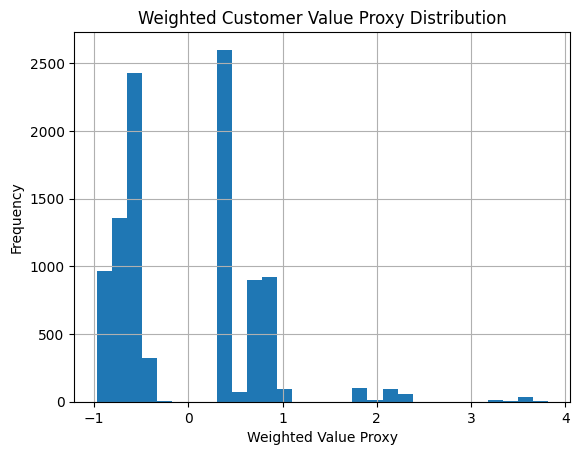

In [89]:
df_processed['weighted_value_proxy'].hist(bins=30)

plt.title("Weighted Customer Value Proxy Distribution")
plt.xlabel("Weighted Value Proxy")
plt.ylabel("Frequency")

plt.show()

The value score distribution is largely shaped by Balance, which carries the majority of the SHAP-proportional weight. Because many customers have near-zero balances, the distribution is bimodal: a sharp peak near the low end (customers with little or no balance) and a broader spread of moderate-to-high scores for customers who hold substantial deposits and engage with multiple products. The higher weight on Balance means that product count alone is insufficient to elevate a customer's score without an accompanying balance contribution.

## Value-Based Customer Segmentation
Customers are classified into value tiers using fixed z-score thresholds applied directly to the `weighted_value_proxy`. Because the proxy is constructed from standardized (zero-mean, unit-variance) features, a score of 0 corresponds to the population average. Thresholds of +0.5 and −0.5 — half a standard deviation above and below the mean — are used to define the three tiers:

* `weighted_value_proxy > +0.5` → **High Value**: customers with above-average financial engagement
* `−0.5 ≤ weighted_value_proxy ≤ +0.5` → **Medium Value**: customers close to the population average
* `weighted_value_proxy < −0.5` → **Low Value**: customers with below-average financial engagement

Fixed z-score boundaries respect the underlying distributional structure and give each tier a clear, reproducible statistical interpretation.

In [90]:
# Fixed z-score thresholds: ±0.5 standard deviations from the mean.
# The weighted_value_proxy is already in standardised units, so these
# thresholds have a direct statistical interpretation.
HIGH_Z = 0.5
LOW_Z  = -0.5

def value_segment(x):
    if x > HIGH_Z:
        return 'High Value'
    elif x >= LOW_Z:
        return 'Medium Value'
    else:
        return 'Low Value'


df_processed['value_segment'] = df_processed['weighted_value_proxy'].apply(value_segment)

print(
    df_processed['value_segment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .astype(str) + '%'
)


value_segment
Low Value       47.07%
Medium Value    29.79%
High Value      23.14%
Name: proportion, dtype: str


The segment distribution above reflects the natural clustering of customers around the population mean. Because the proxy is bimodally distributed, with a dense cluster of near-zero-balance customers and a smaller cluster of high, balance customers, the z-score boundaries produce unequal group sizes by design. This is an expected and interpretable outcome. the Low Value tier captures the dominant cluster of customers with minimal deposit activity, while the High Value tier is intentionally selective, identifying only customers whose combined balance and product engagement places them more than half a standard deviation above average.

## Segment-Level Value and Risk Analysis
To further support risk–value-based prioritization, the analysis proceeds by examining several key customer segments identified in previous sections. These segments are selected based on their distinct behavioral and financial characteristics, particularly those associated with elevated churn risk.

For each segment, a consistent set of metrics is evaluated, including value distribution, average weighted value proxy, segment size, and value share. This structured analysis enables a comprehensive assessment of each group in terms of both economic contribution and potential churn impact.

By comparing these dimensions across segments, it becomes possible to identify which groups represent the most critical targets for retention strategies, considering not only their likelihood of churn but also their overall business value.

In [91]:
df_processed['value_proxy_raw'] = df_processed['Balance'] * df_processed['NumOfProducts']

def analyze_segment(group, df_all):
    # Distribution of value segments (percentage)
    result = group['value_segment'].value_counts(normalize=True).mul(100)
    for k, v in result.items():
        print(f"{k}: {v:.2f}%")

    # Average weighted value proxy of the segment
    print("Avg Weighted Value Proxy:", round(group['weighted_value_proxy'].mean(), 3))

    # Number of customers in the segment
    print("Count:", len(group))

    # Share of total customer value contributed by this segment
    total_value = df_all['value_proxy_raw'].sum()
    group_value = group['value_proxy_raw'].sum()
    value_share = group_value / total_value

    print(f"Value Share: {value_share:.2%}")

### Inactive customers with 3+ products



In [92]:
group_1 = df_processed[
    (df_processed['Active_group'] == 'Inactive') &
    (df_processed['Product_group'] == '3+')
]
print("=== Inactive customers with 3+ products ===")
analyze_segment(group_1, df_processed)

=== Inactive customers with 3+ products ===
High Value: 100.00%
Avg Weighted Value Proxy: 2.315
Count: 184
Value Share: 4.57%


### Retention Strategy Implications
The results indicate that this segment consists entirely of high-value customers (100%), with an average weighted value proxy of 2.913, which is significantly above the population average. This suggests an association between holding multiple products and higher estimated economic value, though this relationship is observational and does not establish a causal link.

However, the segment size is relatively small, with only 184 customers, accounting for 4.57% of total customer value. While each individual customer appears highly valuable based on the proxy measure, the overall contribution of this group to total value is limited due to its small population.

Based on these descriptive patterns, this segment may be a candidate for targeted and personalized retention interventions rather than large-scale resource allocation, though the effectiveness of any such strategy would need to be validated through further experimentation.

### Active customers with 3+ products

In [93]:
group_2 = df_processed[
    (df_processed['Active_group'] == 'Active') &
    (df_processed['Product_group'] == '3+')
]
print("\n=== Active customers with 3+ products ===")
analyze_segment(group_2, df_processed)


=== Active customers with 3+ products ===
High Value: 100.00%
Avg Weighted Value Proxy: 2.34
Count: 142
Value Share: 3.23%


### Retention Strategy Implications
The results show that this segment consists entirely of high-value customers (100%), with an average weighted value proxy of 2.839, indicating a strong level of financial engagement and product usage. This suggests an association between multi-product usage and higher estimated economic value, though causal conclusions cannot be drawn from this observational analysis.

However, the segment size is relatively small, with only 142 customers, contributing 3.23% of total customer value. Although individual customers in this group appear highly valuable based on the proxy measure, the overall contribution of the segment is limited due to its small population.

Based on these descriptive patterns, maintaining engagement and monitoring for signs of disengagement may be a reasonable consideration for this group. Approaches such as proactive communication and service quality improvements could be explored, though their effectiveness would require empirical validation.

### Older inactive customers

In [94]:
group_3 = df_processed[
    (df_processed['Age_group'] == 'Old') &
    (df_processed['Active_group'] == 'Inactive')
]
print("\n=== Older inactive customers ===")
analyze_segment(group_3, df_processed)


=== Older inactive customers ===
Low Value: 55.50%
High Value: 23.71%
Medium Value: 20.79%
Avg Weighted Value Proxy: -0.05
Count: 1472
Value Share: 16.20%


### Retention Strategy Implications
The results show that this segment consists of a mix of medium-value (39.20%), high-value (32.34%), and low-value (28.46%) customers, indicating a relatively balanced value distribution. The average weighted value proxy is 0.025, suggesting that, on average, this group is close to the overall population mean in terms of estimated individual customer value.

The segment size is substantial, with 1,472 customers, contributing 16.20% of total customer value. This highlights that, despite only moderate individual value levels, the group has a notable aggregate presence due to its large population size.

Given these descriptive characteristics, scalable and systematic approaches — such as re-engagement campaigns, personalized communication, or activity-based incentives — may be worth exploring for this segment. However, it should be noted that these recommendations are based solely on observational patterns; actual retention impact would depend on factors not captured in this analysis.

### Older customers with medium or high balances

In [95]:
group_4 = df_processed[
    (df_processed['Age_group'] == 'Old') &
    (df_processed['Balance_group'].isin(['Medium', 'High']))
]
print("\n=== Older customers with medium or high balances ===")
analyze_segment(group_4, df_processed)


=== Older customers with medium or high balances ===
Low Value: 60.70%
High Value: 32.87%
Medium Value: 6.43%
Avg Weighted Value Proxy: -0.054
Count: 2145
Value Share: 33.81%


### Retention Strategy Implications
The results indicate that this segment is strongly concentrated in higher value tiers, with 44.29% high-value customers and 33.24% medium-value customers, while only 22.47% fall into the low-value category. The average weighted value proxy of 0.469 is above the population average, suggesting relatively strong estimated individual customer value within this group.

In addition, this segment is large, comprising 2,145 customers, and contributes 33.81% of total customer value — the largest value share among all analyzed segments. This highlights its substantial aggregate presence in the overall customer base.

Based on these descriptive patterns, this segment may represent a high priority for retention consideration, given its combination of elevated value estimates and large population size. Approaches aimed at protecting existing relationships — such as personalized services or loyalty incentives — could be explored, though their actual business impact would need to be assessed through controlled evaluation rather than inferred from this observational analysis alone.

### Inactive customers with one product

In [96]:
group_5 = df_processed[
    (df_processed['Active_group'] == 'Inactive') &
    (df_processed['Product_group'] == '1')
]
print("\n=== Inactive customers with one product ===")
analyze_segment(group_5, df_processed)


=== Inactive customers with one product ===
Low Value: 92.34%
Medium Value: 7.66%
Avg Weighted Value Proxy: -0.679
Count: 2521
Value Share: 23.35%


### Retention Strategy Implications
The results show that this segment is predominantly composed of low-value customers (44.63%) and medium-value customers (41.21%), with only 14.16% classified as high-value. The average weighted value proxy of -0.564 suggests that, on average, customers in this group have below-average estimated individual value relative to the overall population.

Despite the lower estimated individual value, this segment is the largest among all analyzed groups, with 2,521 customers, contributing 23.35% of total customer value. This indicates that its aggregate presence is driven primarily by population size rather than per-customer value.

Based on these descriptive patterns, cost-efficient and scalable approaches may be more appropriate for this group than resource-intensive interventions. Options such as automated engagement campaigns, basic incentives, or product bundling could be considered, though the suitability and effectiveness of any specific strategy would require further investigation beyond the scope of this analysis.

## Overall Summary and Retention Prioritization
The segment-level analysis reveals descriptive differences across customer groups when considering estimated churn risk, customer value proxy, and segment size. These patterns provide a basis for tentative prioritization, though it is important to note that all findings are observational and do not establish causal relationships between segment membership and churn behavior or business outcomes.

First, certain segments — such as inactive customers with multiple products — show high estimated individual value but represent relatively small populations. Based on these patterns, targeted and personalized retention approaches may be worth exploring for such groups, acknowledging that the value proxy is an approximation rather than a direct measure of revenue impact.

Second, segments such as older inactive customers and older customers with medium or high balances combine elevated predicted churn risk with large population size and substantial estimated value contribution. In particular, older customers with higher balances show the largest aggregate value share among analyzed segments. These patterns suggest that such groups may warrant closer attention in retention planning, though the actual effectiveness of any intervention would depend on factors not captured in this analysis.

Finally, segments like inactive customers with only one product show lower estimated individual value but account for a large share of the customer base. Their aggregate presence is driven by population scale, suggesting that cost-efficient approaches may be more proportionate than resource-intensive ones for this group.

Overall, this analysis offers a descriptive framework for thinking about retention prioritization by combining risk estimates, value proxies, and segment sizes. The integrated perspective provides a richer basis for exploratory decision-making than churn risk alone, while recognizing that any strategic recommendations derived from it would need to be validated through further empirical testing.

# Discussion of Research Impact and Practical Implications
**Research Impact**

This study contributes to the bank customer churn literature in three ways.

First, segmenting the full customer base using continuous predicted churn probabilities captures borderline at-risk customers that binary-label approaches would overlook.

Second, grounding the customer value proxy in mean absolute SHAP values ties the value measure to what the model has learned, rather than to arbitrarily assigned weights.

Third, combining churn risk scores with a value-weighted proxy produces explicit retention priority tiers, directly addressing the gap between predictive modeling and operational decision support. The XGBoost model achieves a ROC-AUC of 0.852 under a leakage-safe pipeline, consistent with comparable studies (Zhang T., 2022; Guliyev & Yerdelen Tatoğlu, 2021).

**Practical Implications**

The framework offers four operational takeaways for retail banking practitioners.

First, the risk–value tiers enable retention budgets to be directed at segments where churn likelihood and customer value jointly are highest while lower-value segments are served through cost-efficient outreach.

Second, the dominant SHAP drivers (age, active membership status, number of products, balance) translate directly into Customer Relationship Management monitoring signals.

Third, SHAP-based explanations provide the customer-level transparency needed for practitioner adoption,.

# Limitations and Ethical Considerations
**Limitations**

*Data quality and scope.* All analyses are conducted on a single publicly available dataset of 10,000 records from an unidentified bank. The dataset lacks time-stamped transaction history, customer lifetime records, and actual revenue figures, which constrains the precision of both the churn risk estimates and the value proxy. Results may not generalize to institutions with different customer demographics, product structures, or geographic contexts.

*Approximate value proxy.* The customer value proxy is constructed from account balance and number of products, weighted by SHAP attributions. While internally consistent with the model's learned representations, it does not reflect actual customer profitability. A rigorous Customer Lifetime Value (CLV) calculation would require transaction-level revenue and cost data not available in this dataset.

*Model assumptions.* XGBoost, like all supervised classifiers, assumes that the historical relationship between input features and churn labels will persist into the future. Structural shifts in customer behavior, product offerings, or macroeconomic conditions could reduce the model's predictive validity over time, necessitating periodic retraining and recalibration.

**Ethical Considerations**

*Algorithmic bias.* The model inherits any biases present in the historical training data. If certain demographic groups were historically underserved or treated differently by the bank, the model may perpetuate those patterns by assigning systematically different churn risk scores to those groups. Fairness audits across demographic subgroups should be conducted before any operational deployment.

*Data privacy.* Churn prediction relies on sensitive personal and financial data. Any real-world deployment must comply with applicable data protection regulations (such as GDPR or PIPEDA), ensure that customer data is used only for stated purposes, and implement appropriate access controls and data minimization practices.

*Real-world implications of automated prioritization.* Automated retention prioritization systems carry the risk of deprioritizing customers classified as low-value, potentially resulting in differential service quality. Banks should ensure that model-driven prioritization supplements rather than replaces human judgment, and that customers are not adversely affected solely on the basis of algorithmic scores. Transparent internal governance and periodic human review of model outputs are advisable.

# Future Work and Recommendations
**Suggested Improvements and Extensions**

*Longitudinal modeling.* Incorporating time-stamped transaction data would allow churn risk to be modeled as a time-varying hazard, improving early-warning timeliness and enabling the model to detect gradual behavioral shifts before exit.

*Richer value measurement.* Replacing the approximate value proxy with a full Customer Lifetime Value (CLV) calculation — incorporating actual revenue, costs, and projected tenure — would ground retention prioritization in verifiable business impact.

*Causal inference.* Applying uplift modeling would distinguish customers who genuinely respond to a retention intervention from those who would churn or stay regardless, enabling more efficient resource allocation.

**Recommendations**

Future implementation should include a scheduled model retraining cadence to account for concept drift, a controlled holdout experiment to validate the business impact of retention interventions, and human review to ensure automated prioritization does not produce differential service quality.

# References
1.	Boozary, P., Sheykhan, S., & GhorbanTanhaei, H. (2024). Bank customer churn prediction using various machine learning algorithms. Journal of Management Information and Decision Sciences, 27(3), 1–18.
2.	Makurumidze, L., Manjoro, W. S., & Makondo, W. (2022). Implementing Random Forest to Predict Churn. International Journal of Computer Science and Mobile Computing, 11(2), 75–84.
3.	Zhang, T. (2022). Prediction and Clustering of Bank Customer Churn Based on XGBoost and K-means. BCP Business & Management, GEBM 2022, 23, 360–366.
4.	Zhang, W. (2023). Bank Customer Churn Analysis and Prediction. EAI (MSIEID 2022).
5.	Guliyev, H., & Yerdelen Tatoğlu, F. (2021). Customer churn analysis in the banking sector: Evidence from explainable machine learning models. Journal of Applied Microeconometrics, 1(2), 85–99.
6.	(AIMS Press). (2025). Prediction of bank credit customers churn based on machine learning and interpretability analysis. Data Science in Finance and Economics.
